# Recommandation Séquentielle par Apprentissage par Renforcement

| Phase | Méthode | Statut |
|-------|---------|--------|
| 0 | Baseline aléatoire | ✅ |
| 1 | Q-Learning (tabular) | ✅ |
| 2 | Deep Q-Network (DQN) | 🔜 |
| 3 | GRU + DQN (séquentiel) | 🔜 |

---

## Setup

In [1]:
import sys, os, json as _json
sys.path.append('..')

MODELS_DIR = os.path.join('..', 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from env.recommendation_env import RecommendationEnv
from utils.metrics import (
    EpisodeMetrics, TrainingTracker,
    compute_summary, evaluate_agent, RandomAgent
)

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')

COLORS = {'random': '#e74c3c', 'qlearning': '#2980b9', 'ql_opt': '#f39c12', 'dqn': '#27ae60', 'gru_dqn': '#8e44ad'}

### Choix du dataset

In [2]:
USE_AMAZON = False   # ← passe à True après : python data/amazon_loader.py

if USE_AMAZON:
    env_factory = lambda seed=42: RecommendationEnv.from_amazon(seed=seed)
    _tmp = RecommendationEnv.from_amazon()
else:
    env_factory = lambda seed=42: RecommendationEnv(seed=seed)
    _tmp = RecommendationEnv()

N_ITEMS = _tmp.n_items
CATALOG = _tmp.catalog
del _tmp

print(f'Mode  : {"Amazon Electronics" if USE_AMAZON else "Synthétique"}')
print(f'Items : {N_ITEMS}')
print(f'Ex.   : {CATALOG[0]}')

Mode  : Synthétique
Items : 50
Ex.   : {'id': 0, 'asin': 'SYN0000', 'title': 'Tech item 0', 'category': 'tech', 'price': 388.11, 'avg_rating': 3.88, 'click_prob': 0.496, 'n_reviews': 261}


---
## Formalisation MDP

| Symbole | Définition | Dans notre projet |
|---------|-----------|-------------------|
| $\mathcal{S}$ | États | Index du dernier item vu |
| $\mathcal{A}$ | Actions | Index de l'item à recommander |
| $\mathcal{P}$ | Transition | Clic → s' = item recommandé |
| $\mathcal{R}$ | Récompense | +1 clic, +3 achat, 0 ignoré, −0.5 répétition |
| $\gamma$ | Actualisation | 0.99 |

$$G_t = \sum_{k=0}^{T} \gamma^k R_{t+k}$$

---

## Phase 0 — Baseline aléatoire

In [3]:
random_agent  = RandomAgent(n_actions=N_ITEMS, seed=42)
random_eval   = evaluate_agent(random_agent, env_factory, n_episodes=300, seed=0)
random_summary = compute_summary(random_eval)

print('=== Baseline aléatoire ===')
for k, v in random_summary.items():
    print(f'  {k:<20} {v}')

=== Baseline aléatoire ===
  n_episodes           300
  reward_mean          1.2633333333333334
  reward_std           1.1513711632464814
  reward_min           -1.0
  reward_max           5.5
  ctr_mean             0.12666666666666668
  purchase_rate        0.004333333333333333
  engagement_rate      0.131
  hit_rate             0.77
  diversity_mean       0.9153333333333334
  repeat_rate          0.026666666666666672
  coverage             50
  td_error_mean        0.0


---
## Phase 1 — Q-Learning

In [4]:
class QLearningAgent:
    def __init__(self, n_states, n_actions, alpha=0.1, gamma=0.99,
                 epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.995, seed=42):
        self.n_states, self.n_actions = n_states, n_actions
        self.alpha, self.gamma = alpha, gamma
        self.epsilon, self.epsilon_min, self.epsilon_decay = epsilon, epsilon_min, epsilon_decay
        self.rng = np.random.default_rng(seed)
        self.Q   = np.zeros((n_states, n_actions))

    def act(self, state):
        if self.rng.random() < self.epsilon:
            return int(self.rng.integers(0, self.n_actions))
        return int(np.argmax(self.Q[state]))

    def update(self, state, action, reward, next_state):
        td_target = reward + self.gamma * np.max(self.Q[next_state])
        td_error  = td_target - self.Q[state, action]
        self.Q[state, action] += self.alpha * td_error
        return abs(td_error)

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    @property
    def size_mb(self): return self.Q.nbytes / 1024**2


print(f'Q-table 50 items   : {50**2:>12,} valeurs  — {50**2*8/1024**2:.3f} Mo')
print(f'Q-table 10k items  : {10000**2:>12,} valeurs  — {10000**2*8/1024**2:.0f} Mo')
print(f'Q-table 100k items : {100000**2:>12,} valeurs  — {100000**2*8/1024**3:.0f} Go  ← impossible')

Q-table 50 items   :        2,500 valeurs  — 0.019 Mo
Q-table 10k items  :  100,000,000 valeurs  — 763 Mo
Q-table 100k items : 10,000,000,000 valeurs  — 75 Go  ← impossible


### Entraînement avec collecte de métriques

In [5]:
def train_q_learning(n_episodes=1000, seed=42):
    env     = env_factory(seed=seed)
    agent   = QLearningAgent(n_states=N_ITEMS, n_actions=N_ITEMS, seed=seed)
    tracker = TrainingTracker()

    for ep_idx in range(n_episodes):
        state = env.reset()
        ep    = EpisodeMetrics()
        done  = False

        while not done:
            action = agent.act(state)
            next_state, reward, done, info = env.step(action)
            td_err = agent.update(state, action, reward, next_state)

            ep.total_reward += reward
            ep.n_steps      += 1
            ep.recommended.append(action)
            ep.td_errors.append(td_err)

            event = info.get('event', '')
            if event == 'click':   ep.n_clicks  += 1
            elif event == 'buy':   ep.n_buys    += 1
            elif event == 'ignore':ep.n_ignores += 1
            elif event == 'repeat':ep.n_repeats += 1

            state = next_state

        agent.decay_epsilon()
        tracker.log(ep)

        if (ep_idx + 1) % 200 == 0:
            last = tracker.episodes[-200:]
            mean_r   = np.mean([e.total_reward for e in last])
            mean_ctr = np.mean([e.ctr          for e in last])
            print(f'Ep {ep_idx+1:4d} | Reward : {mean_r:.3f} | CTR : {mean_ctr:.3f} | ε : {agent.epsilon:.3f}')

    return agent, tracker


print('Entraînement Q-Learning...')
q_agent, q_tracker = train_q_learning(n_episodes=1000)

Entraînement Q-Learning...
Ep  200 | Reward : 1.502 | CTR : 0.138 | ε : 0.367
Ep  400 | Reward : 1.565 | CTR : 0.142 | ε : 0.135
Ep  600 | Reward : 1.610 | CTR : 0.136 | ε : 0.050
Ep  800 | Reward : 1.685 | CTR : 0.142 | ε : 0.050
Ep 1000 | Reward : 1.720 | CTR : 0.152 | ε : 0.050


---
## Évaluation — Métriques

On distingue deux types de métriques :

| Famille | Métriques | Ce qu'elles mesurent |
|---------|-----------|---------------------|
| **RL** | Reward, TD Error | Qualité de l'apprentissage |
| **Recommandation** | CTR, Purchase Rate, Hit Rate, Diversité, Couverture | Qualité des recommandations |

L'évaluation se fait en **mode exploitation pure** (ε = 0) sur 300 épisodes.

In [6]:
q_eval    = evaluate_agent(q_agent, env_factory, n_episodes=300, seed=99)
q_summary = compute_summary(q_eval)

print('=== Q-Learning (exploitation) ===')
for k, v in q_summary.items():
    print(f'  {k:<20} {v}')

=== Q-Learning (exploitation) ===
  n_episodes           300
  reward_mean          1.6366666666666667
  reward_std           1.3227454613626748
  reward_min           0.0
  reward_max           7.0
  ctr_mean             0.14400000000000002
  purchase_rate        0.008333333333333333
  engagement_rate      0.15233333333333335
  hit_rate             0.8
  diversity_mean       0.2343333333333333
  repeat_rate          0.010666666666666668
  coverage             25
  td_error_mean        0.0


### 📊 Graphe 1 — Reward cumulée au cours de l'entraînement

**Ce que montre ce graphe :**  
L'évolution de la récompense totale par épisode au fil du temps.

**Comment l'interpréter :**
- La courbe brute (transparente) est très bruitée car chaque épisode est différent (profil user aléatoire).
- La courbe lissée (moyenne mobile) révèle la tendance réelle d'apprentissage.
- Une courbe qui monte et se stabilise = l'agent apprend et converge.
- Si la courbe reste plate = l'agent n'apprend rien (problème de hyperparamètres ou de design).
- La ligne rouge = reward du random : tout ce qui est au-dessus = gain réel.

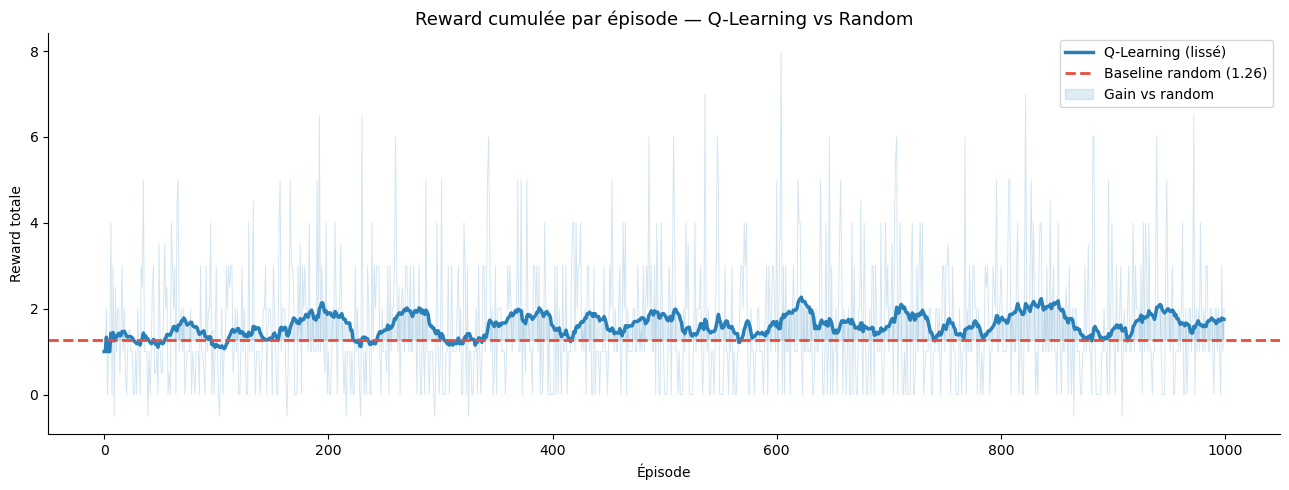

In [7]:
def smooth(values, window=30):
    return pd.Series(values).rolling(window, min_periods=1).mean().values

q_rewards  = q_tracker.get('total_reward')
random_r   = random_summary['reward_mean']

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(q_rewards, alpha=0.2, color=COLORS['qlearning'], linewidth=0.7)
ax.plot(smooth(q_rewards), color=COLORS['qlearning'], linewidth=2.5, label='Q-Learning (lissé)')
ax.axhline(random_r, color=COLORS['random'], linestyle='--', linewidth=2,
           label=f'Baseline random ({random_r:.2f})')
ax.fill_between(range(len(q_rewards)), random_r, smooth(q_rewards),
                where=np.array(smooth(q_rewards)) > random_r,
                alpha=0.15, color=COLORS['qlearning'], label='Gain vs random')
ax.set_title('Reward cumulée par épisode — Q-Learning vs Random', fontsize=13)
ax.set_xlabel('Épisode')
ax.set_ylabel('Reward totale')
ax.legend()
plt.tight_layout()
plt.savefig('../data/reward_training.png', dpi=150)
plt.show()

### 📊 Graphe 2 — CTR & Taux d'engagement au cours de l'entraînement

**CTR (Click-Through Rate)** = clics / recommandations totales  
**Engagement Rate** = (clics + achats) / recommandations totales

**Comment l'interpréter :**
- Un CTR qui augmente = l'agent apprend à recommander des items pertinents pour le profil utilisateur.
- L'écart entre CTR et engagement rate révèle la proportion d'achats : un gap large = l'agent déclenche des achats, pas juste des clics.
- En production réelle, le CTR est la métrique business principale des systèmes de recommandation.

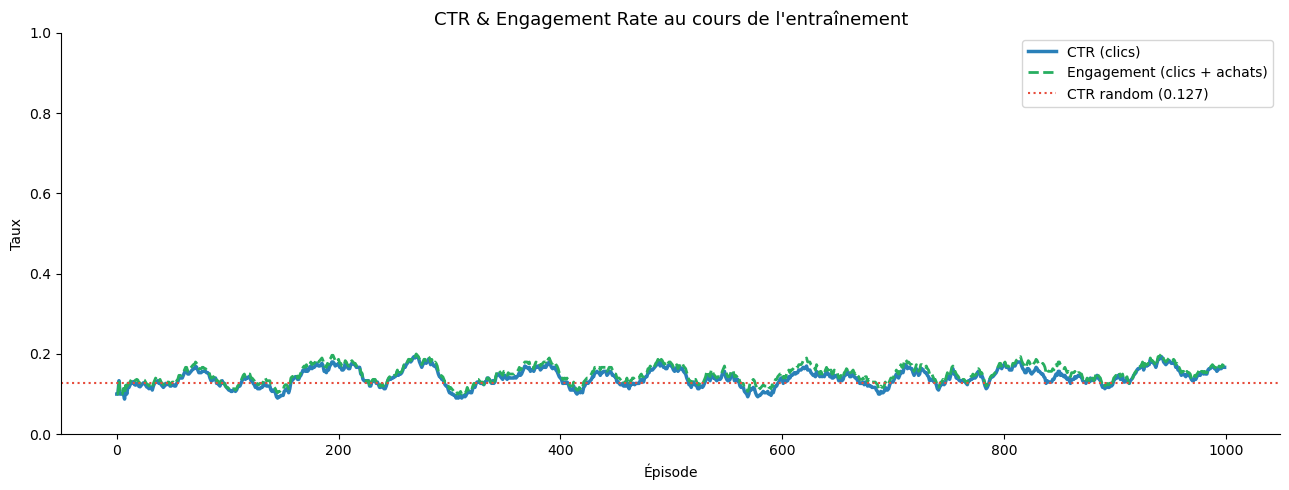

CTR final (moy. 200 derniers ep.) : 0.152
CTR random                        : 0.127
Amélioration CTR                  : +0.025


In [8]:
ctrs = q_tracker.get('ctr')
engs = q_tracker.get('engagement_rate')

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(smooth(ctrs), color=COLORS['qlearning'], linewidth=2.5, label='CTR (clics)')
ax.plot(smooth(engs), color=COLORS['dqn'], linewidth=2, linestyle='--', label='Engagement (clics + achats)')
ax.axhline(random_summary['ctr_mean'], color=COLORS['random'], linestyle=':',
           linewidth=1.5, label=f"CTR random ({random_summary['ctr_mean']:.3f})")
ax.set_title('CTR & Engagement Rate au cours de l\'entraînement', fontsize=13)
ax.set_xlabel('Épisode')
ax.set_ylabel('Taux')
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.savefig('../data/ctr_training.png', dpi=150)
plt.show()

print(f"CTR final (moy. 200 derniers ep.) : {np.mean(ctrs[-200:]):.3f}")
print(f"CTR random                        : {random_summary['ctr_mean']:.3f}")
print(f"Amélioration CTR                  : +{np.mean(ctrs[-200:]) - random_summary['ctr_mean']:.3f}")

### 📊 Graphe 3 — Diversité & Repeat Rate

**Diversité** = items uniques recommandés / total recommandations  
**Repeat Rate** = recommandations déjà vues / total (pénalisées à −0.5)

**Comment l'interpréter :**
- Une diversité élevée = l'agent explore le catalogue, évite la "bulle de filtre".
- Un repeat rate élevé = l'agent recommande les mêmes items en boucle → mauvaise expérience utilisateur.
- Le compromis idéal : diversité haute + repeat rate bas.
- En début d'entraînement (ε ≈ 1), la diversité est naturellement haute car l'agent explore. Elle peut baisser à mesure qu'il exploite des items "sûrs".

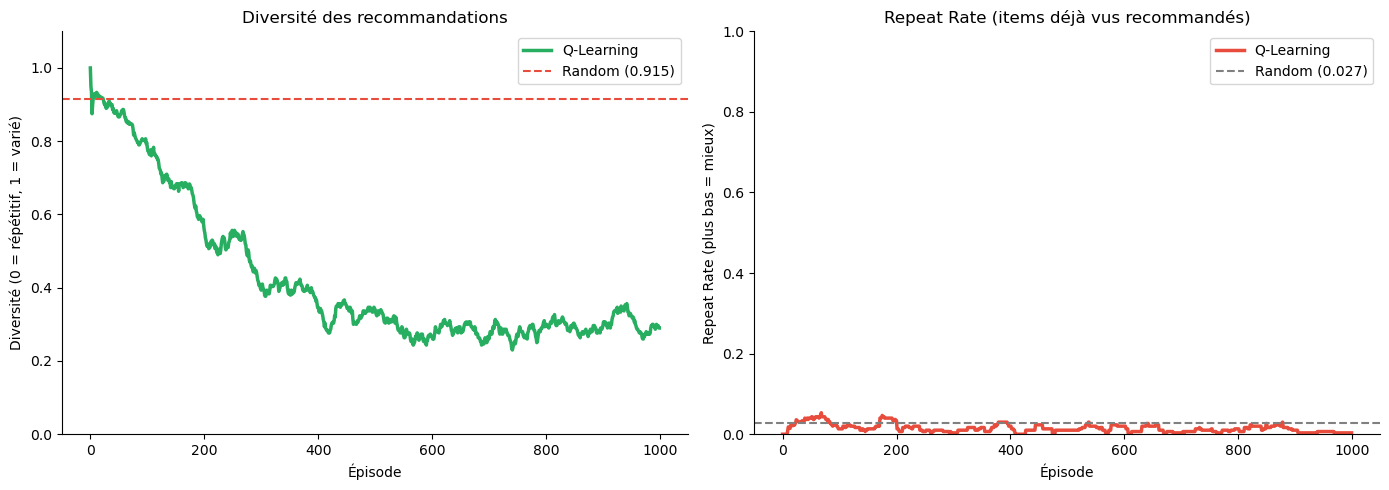

In [9]:
divs = q_tracker.get('diversity')
reps = q_tracker.get('repeat_rate')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(smooth(divs), color=COLORS['dqn'], linewidth=2.5, label='Q-Learning')
ax.axhline(random_summary['diversity_mean'], color=COLORS['random'],
           linestyle='--', linewidth=1.5, label=f"Random ({random_summary['diversity_mean']:.3f})")
ax.set_title('Diversité des recommandations')
ax.set_xlabel('Épisode')
ax.set_ylabel('Diversité (0 = répétitif, 1 = varié)')
ax.set_ylim(0, 1.1)
ax.legend()

ax2 = axes[1]
ax2.plot(smooth(reps), color=COLORS['random'], linewidth=2.5, label='Q-Learning')
ax2.axhline(random_summary['repeat_rate'], color='gray',
            linestyle='--', linewidth=1.5, label=f"Random ({random_summary['repeat_rate']:.3f})")
ax2.set_title('Repeat Rate (items déjà vus recommandés)')
ax2.set_xlabel('Épisode')
ax2.set_ylabel('Repeat Rate (plus bas = mieux)')
ax2.set_ylim(0, 1)
ax2.legend()

plt.tight_layout()
plt.savefig('../data/diversity_repeat.png', dpi=150)
plt.show()

### 📊 Graphe 4 — TD Error (stabilité de l'apprentissage)

**TD Error** = $|r + \gamma \max Q(s', a') - Q(s, a)|$

**Comment l'interpréter :**
- L'erreur TD mesure à quel point les prédictions de valeur Q sont fausses.
- En début d'entraînement : Q-table = 0 partout → les erreurs sont grandes.
- Au fil du temps : la Q-table converge → les erreurs diminuent et se stabilisent.
- Une erreur qui **ne baisse pas** = l'agent n'apprend pas (alpha trop petit, reward trop sparse).
- Une erreur qui **explose** = instabilité (alpha trop grand, problème de bootstrap).

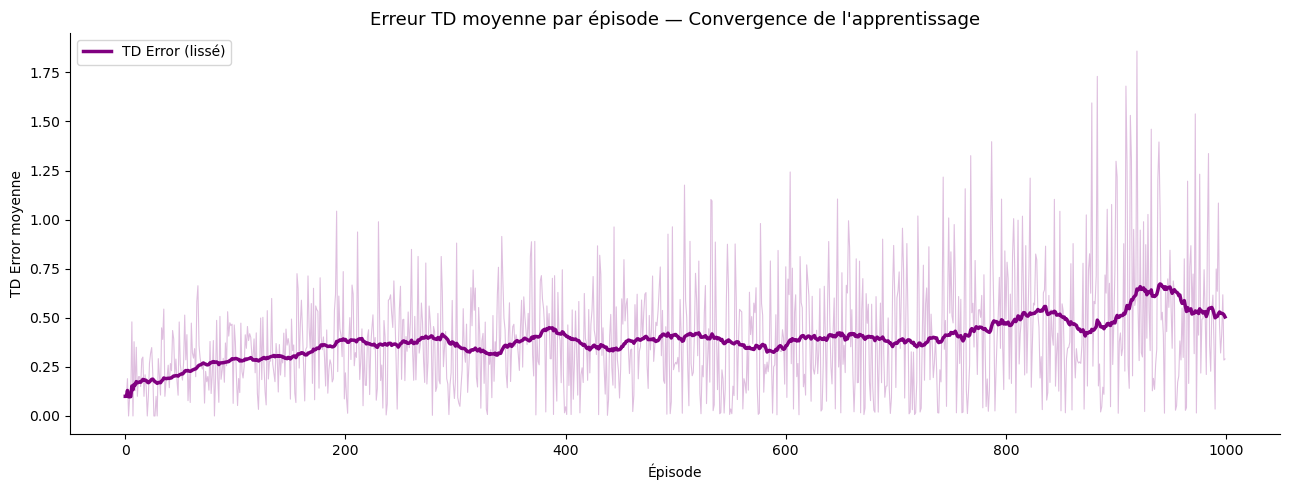

TD Error début (100 premiers) : 0.2494
TD Error fin   (100 derniers) : 0.5806
Réduction                     : --132.8%


In [10]:
td_errors = q_tracker.get('mean_td_error')

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(td_errors, alpha=0.25, color='purple', linewidth=0.8)
ax.plot(smooth(td_errors, window=50), color='purple', linewidth=2.5, label='TD Error (lissé)')
ax.set_title('Erreur TD moyenne par épisode — Convergence de l\'apprentissage', fontsize=13)
ax.set_xlabel('Épisode')
ax.set_ylabel('TD Error moyenne')
ax.legend()
plt.tight_layout()
plt.savefig('../data/td_error.png', dpi=150)
plt.show()

print(f'TD Error début (100 premiers) : {np.mean(td_errors[:100]):.4f}')
print(f'TD Error fin   (100 derniers) : {np.mean(td_errors[-100:]):.4f}')
print(f'Réduction                     : -{(1 - np.mean(td_errors[-100:])/np.mean(td_errors[:100]))*100:.1f}%')

### 📊 Graphe 5 — Heatmap Q-table

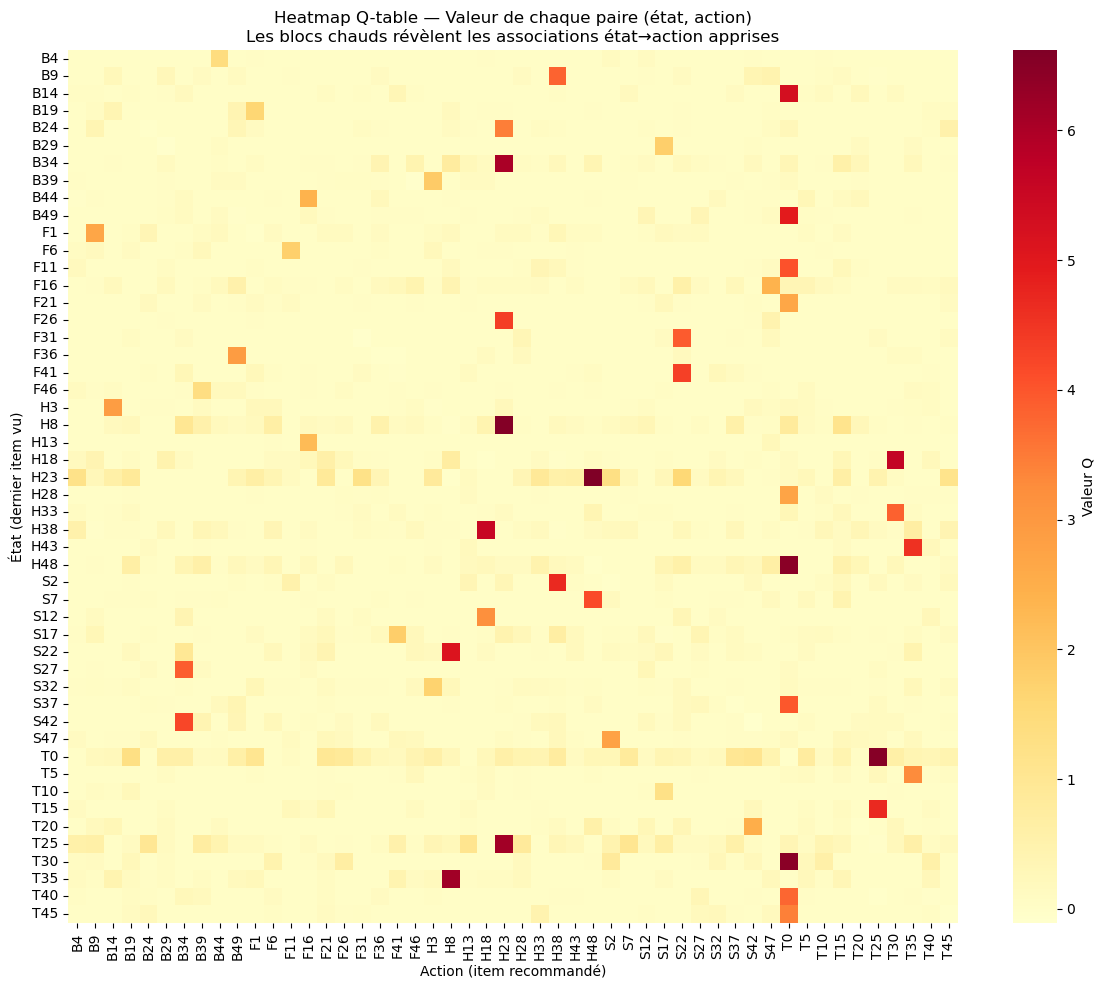

In [11]:
if N_ITEMS <= 100:
    sorted_ids = sorted(range(N_ITEMS), key=lambda i: CATALOG[i]['category'])
    Q_sorted   = q_agent.Q[np.ix_(sorted_ids, sorted_ids)]
    labels     = [f"{CATALOG[i]['category'][0].upper()}{i}" for i in sorted_ids]
else:
    top50      = np.argsort(q_agent.Q.sum(axis=1))[-50:]
    sorted_ids = sorted(top50, key=lambda i: CATALOG[i]['category'])
    Q_sorted   = q_agent.Q[np.ix_(sorted_ids, sorted_ids)]
    labels     = [f"{CATALOG[i]['category'][0].upper()}{i}" for i in sorted_ids]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(Q_sorted, ax=ax, cmap='YlOrRd',
            xticklabels=labels, yticklabels=labels,
            cbar_kws={'label': 'Valeur Q'})
ax.set_title('Heatmap Q-table — Valeur de chaque paire (état, action)\n'
             'Les blocs chauds révèlent les associations état→action apprises', fontsize=12)
ax.set_xlabel('Action (item recommandé)')
ax.set_ylabel('État (dernier item vu)')
plt.tight_layout()
plt.savefig('../data/q_table_heatmap.png', dpi=150)
plt.show()

**Comment lire cette heatmap :**
- Chaque ligne = un état (dernier item vu par l'utilisateur).
- Chaque colonne = une action (item à recommander).
- Une case chaude (rouge/orange) = l'agent a appris que cette recommandation est rentable dans cet état.
- Les **blocs par catégorie** (B=books, F=fashion, H=home, S=sport, T=tech) montrent si l'agent a appris la cohérence catégorielle.
- Idéalement, les cases les plus chaudes devraient être dans des blocs de même catégorie (recommander tech quand l'user regarde du tech).

### 📊 Graphe 6 — Distribution des récompenses & Couverture catalogue

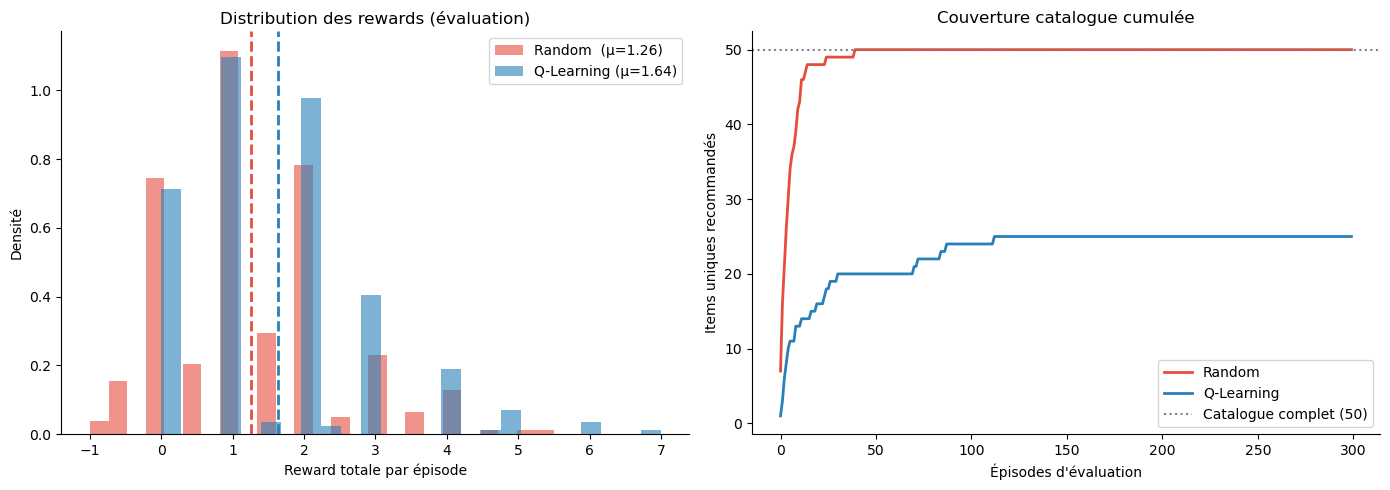

In [12]:
q_eval_rewards  = [e.total_reward for e in q_eval]
rand_eval_rewards = [e.total_reward for e in random_eval]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution rewards
ax = axes[0]
ax.hist(rand_eval_rewards, bins=25, alpha=0.6, color=COLORS['random'],
        label=f"Random  (μ={random_summary['reward_mean']:.2f})", density=True)
ax.hist(q_eval_rewards, bins=25, alpha=0.6, color=COLORS['qlearning'],
        label=f"Q-Learning (μ={q_summary['reward_mean']:.2f})", density=True)
ax.axvline(random_summary['reward_mean'], color=COLORS['random'], linestyle='--', linewidth=2)
ax.axvline(q_summary['reward_mean'],      color=COLORS['qlearning'], linestyle='--', linewidth=2)
ax.set_title('Distribution des rewards (évaluation)')
ax.set_xlabel('Reward totale par épisode')
ax.set_ylabel('Densité')
ax.legend()

# Couverture catalogue
ax2 = axes[1]
rand_items = set()
q_items    = set()
rand_cov, q_cov = [], []
for re, qe in zip(random_eval, q_eval):
    rand_items.update(re.recommended)
    q_items.update(qe.recommended)
    rand_cov.append(len(rand_items))
    q_cov.append(len(q_items))

ax2.plot(rand_cov, color=COLORS['random'], linewidth=2, label='Random')
ax2.plot(q_cov,   color=COLORS['qlearning'], linewidth=2, label='Q-Learning')
ax2.axhline(N_ITEMS, color='gray', linestyle=':', linewidth=1.5, label=f'Catalogue complet ({N_ITEMS})')
ax2.set_title('Couverture catalogue cumulée')
ax2.set_xlabel('Épisodes d\'évaluation')
ax2.set_ylabel('Items uniques recommandés')
ax2.legend()

plt.tight_layout()
plt.savefig('../data/distribution_coverage.png', dpi=150)
plt.show()

**Couverture catalogue :**  
- Un agent qui couvre peu d'items crée une "bulle" : les mêmes items populaires sont toujours recommandés.
- Le random couvre naturellement tout le catalogue (c'est son seul avantage).
- Un bon agent doit trouver l'équilibre : recommander les bons items *et* explorer le catalogue.

### 📊 Graphe 7 — Tableau de bord comparatif Random vs Q-Learning

In [13]:
metrics_labels = {
    'reward_mean':     ('Reward moyenne',      'max', '{:.3f}'),
    'ctr_mean':        ('CTR',                 'max', '{:.3f}'),
    'purchase_rate':   ('Taux d\'achat',       'max', '{:.3f}'),
    'engagement_rate': ('Engagement rate',     'max', '{:.3f}'),
    'hit_rate':        ('Hit rate',            'max', '{:.3f}'),
    'diversity_mean':  ('Diversité',           'max', '{:.3f}'),
    'repeat_rate':     ('Repeat rate',         'min', '{:.3f}'),
    'coverage':        ('Couverture items',    'max', '{:d}'),
}

rows = []
for key, (label, best, fmt) in metrics_labels.items():
    r_val = random_summary[key]
    q_val = q_summary[key]
    if best == 'max':
        winner = 'Q-Learning' if q_val > r_val else 'Random'
        delta  = q_val - r_val
    else:
        winner = 'Q-Learning' if q_val < r_val else 'Random'
        delta  = r_val - q_val  # positif = Q-Learning meilleur
    rows.append({
        'Métrique':    label,
        'Random':      fmt.format(r_val) if 'd' not in fmt else fmt.format(int(r_val)),
        'Q-Learning':  fmt.format(q_val) if 'd' not in fmt else fmt.format(int(q_val)),
        'Δ':           f'{delta:+.3f}' if 'd' not in fmt else f'{int(delta):+d}',
        'Meilleur':    winner,
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

        Métrique Random Q-Learning      Δ   Meilleur
  Reward moyenne  1.263      1.637 +0.373 Q-Learning
             CTR  0.127      0.144 +0.017 Q-Learning
    Taux d'achat  0.004      0.008 +0.004 Q-Learning
 Engagement rate  0.131      0.152 +0.021 Q-Learning
        Hit rate  0.770      0.800 +0.030 Q-Learning
       Diversité  0.915      0.234 -0.681     Random
     Repeat rate  0.027      0.011 +0.016 Q-Learning
Couverture items     50         25    -25     Random


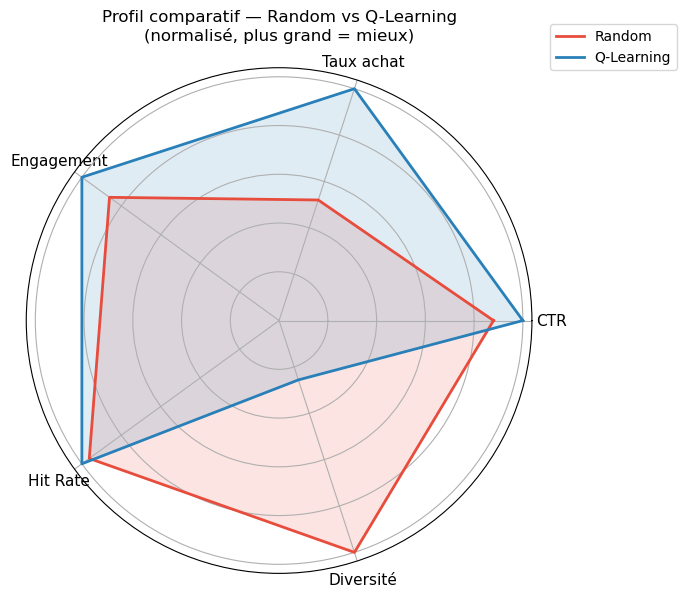

In [14]:
# Radar chart — profil visuel des deux agents
metrics_radar = ['ctr_mean', 'purchase_rate', 'engagement_rate',
                 'hit_rate', 'diversity_mean']
labels_radar  = ['CTR', 'Taux achat', 'Engagement', 'Hit Rate', 'Diversité']

rand_vals = [random_summary[m] for m in metrics_radar]
q_vals    = [q_summary[m]      for m in metrics_radar]

# Normaliser 0-1 pour le radar
max_vals = [max(r, q) + 1e-9 for r, q in zip(rand_vals, q_vals)]
rand_n   = [v / m for v, m in zip(rand_vals, max_vals)]
q_n      = [v / m for v, m in zip(q_vals,    max_vals)]

angles  = np.linspace(0, 2 * np.pi, len(labels_radar), endpoint=False).tolist()
rand_n += rand_n[:1]; q_n += q_n[:1]; angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.plot(angles, rand_n, color=COLORS['random'],    linewidth=2, label='Random')
ax.fill(angles, rand_n, color=COLORS['random'],    alpha=0.15)
ax.plot(angles, q_n,    color=COLORS['qlearning'], linewidth=2, label='Q-Learning')
ax.fill(angles, q_n,    color=COLORS['qlearning'], alpha=0.15)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_radar, fontsize=11)
ax.set_yticklabels([])
ax.set_title('Profil comparatif — Random vs Q-Learning\n(normalisé, plus grand = mieux)',
             fontsize=12, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig('../data/radar_comparison.png', dpi=150)
plt.show()

**Comment lire le radar :**
- Plus la surface colorée est grande, meilleur est l'agent sur ces métriques.
- Si Q-Learning surpasse Random sur toutes les dimensions → l'apprentissage est efficace.
- Si Random est meilleur sur la diversité → le Q-Learning se concentre trop sur quelques items (exploitation trop agressive). C'est une limite connue des agents tabulaires.

---
## Diagnostic — Pourquoi ces résultats ?

L'analyse des 4 graphes précédents révèle **4 problèmes distincts** :

### Problème 1 — Reward sinusoïdale, jamais stable
**Cause :** La Q-table apprend **une politique moyenne sur 4 profils** (tech, fashion, sport, random).
Chaque épisode change de profil → les mises à jour se contredisent. Ce que l'agent apprend pour "tech" est écrasé par l'épisode "fashion" suivant.

### Problème 2 — CTR instable
**Cause :** `epsilon_decay=0.995` trop rapide. L'agent bascule en exploitation avant d'avoir assez exploré, ses Q-values sont fausses pour le profil courant → le CTR replonge.

### Problème 3 — Diversité effondrée (0.23 vs 0.92 pour le random)
**Cause :** `epsilon_min=0.05` trop bas. Avec ε=5%, l'agent exploite à 95% → recommande toujours les mêmes 25 items "sûrs" sur 50. Bulle de filtre sévère.

### Problème 4 — TD Error qui croît au lieu de décroître
**Cause :** `alpha=0.1` trop grand + `gamma=0.99` inadapté à des sessions de 10 steps.
Bootstrap incontrôlé : $Q(s,a) \leftarrow r + 0.99 \times \max Q(s')$, et comme $\max Q(s')$ grandit à chaque update, la cible grandit aussi → les Q-values s'emballent.

---
## Optimisation Q-Learning

### Fixes appliqués

| Paramètre | Avant | Après | Raison |
|-----------|-------|-------|--------|
| `alpha` | 0.10 | **0.03** | Mise à jour lente → Q-values stables, TD error converge |
| `gamma` | 0.99 | **0.90** | Adapté aux sessions courtes (10 steps max) |
| `epsilon_min` | 0.05 | **0.12** | Maintient la diversité même en exploitation |
| `epsilon_decay` | 0.995 | **0.998** | Exploration plus longue avant exploitation |
| `n_episodes` | 1000 | **3000** | Plus de temps pour converger avec alpha bas |
| **reward shaping** | — | **+0.2 si nouvelle catégorie** | Incite l'agent à diversifier |

In [15]:
import itertools

# ── Fonction d'entraînement d'abord ────────────────────────────────────────
def run_training_opt(agent_kwargs, n_episodes=5000, seed=42, diversity_bonus=0.0):
    env     = env_factory(seed=seed)
    agent   = QLearningAgent(n_states=N_ITEMS, n_actions=N_ITEMS, seed=seed, **agent_kwargs)
    tracker = TrainingTracker()
    for ep_idx in range(n_episodes):
        state     = env.reset()
        ep        = EpisodeMetrics()
        done      = False
        seen_cats = {CATALOG[state]['category']}
        while not done:
            action = agent.act(state)
            next_state, reward, done, info = env.step(action)
            action_cat = CATALOG[action]['category']
            if diversity_bonus > 0 and action_cat not in seen_cats and info.get('event') != 'repeat':
                reward    += diversity_bonus
                seen_cats.add(action_cat)
            td_err = agent.update(state, action, reward, next_state)
            ep.total_reward += reward
            ep.n_steps      += 1
            ep.recommended.append(action)
            ep.td_errors.append(td_err)
            ev = info.get('event', '')
            if ev == 'click':    ep.n_clicks  += 1
            elif ev == 'buy':    ep.n_buys    += 1
            elif ev == 'ignore': ep.n_ignores += 1
            elif ev == 'repeat': ep.n_repeats += 1
            state = next_state
        agent.decay_epsilon()
        tracker.log(ep)
        if (ep_idx + 1) % 1000 == 0:
            last = tracker.episodes[-1000:]
            print(f'  Ep {ep_idx+1:5d} | R={np.mean([e.total_reward for e in last]):.3f} | CTR={np.mean([e.ctr for e in last]):.3f} | Div={np.mean([e.diversity for e in last]):.3f} | eps={agent.epsilon:.3f}')
    return agent, tracker

# ── Grid search configuration ──────────────────────────────────────────────
QL_GRID = {
    'alpha':         [0.01, 0.03, 0.05],
    'epsilon_min':   [0.02, 0.05, 0.08],
    'epsilon_decay': [0.994, 0.997, 0.9995],
}
QL_FIXED = dict(gamma=0.90)
QL_GRID_EPISODES  = 400
QL_EVAL_EPISODES  = 60
QL_TRAIN_EPISODES = 5000

def _ql_score(kwargs, n_ep, seed):
    a, t = run_training_opt({**QL_FIXED, **kwargs}, n_episodes=n_ep, seed=seed, diversity_bonus=0.0)
    ev = evaluate_agent(a, env_factory, n_episodes=QL_EVAL_EPISODES, seed=seed+1)
    return compute_summary(ev)['reward_mean']

keys   = list(QL_GRID.keys())
combos = list(itertools.product(*QL_GRID.values()))
print(f'Q-Learning grid search : {len(combos)} configs x {QL_GRID_EPISODES} ep (NO diversity bonus)')

ql_results = []
for i, vals in enumerate(combos):
    kw = dict(zip(keys, vals))
    score = _ql_score(kw, QL_GRID_EPISODES, seed=7)
    ql_results.append((score, kw))
    print(f'  [{i+1:2d}/{len(combos)}] {kw}  ->  reward={score:.4f}')

ql_results.sort(key=lambda x: -x[0])
best_ql_score, best_ql_params = ql_results[0]
best_ql_params = {**QL_FIXED, **best_ql_params}
print(f'\nMeilleurs params QL : {best_ql_params}  (reward={best_ql_score:.4f})')

COLORS['ql_opt'] = '#f39c12'
print(f'\nEntrainement Q-Learning optimise ({QL_TRAIN_EPISODES} episodes) avec {best_ql_params}...')
q_opt_agent, q_opt_tracker = run_training_opt(best_ql_params, n_episodes=QL_TRAIN_EPISODES, diversity_bonus=0.0)
q_opt_eval    = evaluate_agent(q_opt_agent, env_factory, n_episodes=300, seed=99)
q_opt_summary = compute_summary(q_opt_eval)
print(f"R={q_opt_summary['reward_mean']:.3f} | CTR={q_opt_summary['ctr_mean']:.3f} | Div={q_opt_summary['diversity_mean']:.3f} | Cov={q_opt_summary['coverage']:.3f}")

# ── Export ───────────────────────────────────────────────────────────────────
import numpy as _np
_np.save(os.path.join(MODELS_DIR, 'q_table.npy'), q_opt_agent.Q)
with open(os.path.join(MODELS_DIR, 'q_learning_params.json'), 'w') as _f:
    _json.dump({'hyperparams': best_ql_params, 'n_items': N_ITEMS,
               'reward_mean': float(q_opt_summary['reward_mean']),
               'ctr_mean':    float(q_opt_summary['ctr_mean']),
               'diversity':   float(q_opt_summary['diversity_mean']),
               'note': 'Diversity bonus=0 (removed)'}, _f, indent=2)
print(f'Modele sauvegarde -> {MODELS_DIR}/q_table.npy')


Q-Learning grid search : 27 configs x 400 ep (NO diversity bonus)
  [ 1/27] {'alpha': 0.01, 'epsilon_min': 0.02, 'epsilon_decay': 0.994}  ->  reward=1.6500
  [ 2/27] {'alpha': 0.01, 'epsilon_min': 0.02, 'epsilon_decay': 0.997}  ->  reward=1.5333
  [ 3/27] {'alpha': 0.01, 'epsilon_min': 0.02, 'epsilon_decay': 0.9995}  ->  reward=1.3833
  [ 4/27] {'alpha': 0.01, 'epsilon_min': 0.05, 'epsilon_decay': 0.994}  ->  reward=1.6500
  [ 5/27] {'alpha': 0.01, 'epsilon_min': 0.05, 'epsilon_decay': 0.997}  ->  reward=1.5333
  [ 6/27] {'alpha': 0.01, 'epsilon_min': 0.05, 'epsilon_decay': 0.9995}  ->  reward=1.3833
  [ 7/27] {'alpha': 0.01, 'epsilon_min': 0.08, 'epsilon_decay': 0.994}  ->  reward=1.6500
  [ 8/27] {'alpha': 0.01, 'epsilon_min': 0.08, 'epsilon_decay': 0.997}  ->  reward=1.5333
  [ 9/27] {'alpha': 0.01, 'epsilon_min': 0.08, 'epsilon_decay': 0.9995}  ->  reward=1.3833
  [10/27] {'alpha': 0.03, 'epsilon_min': 0.02, 'epsilon_decay': 0.994}  ->  reward=1.6500
  [11/27] {'alpha': 0.03, 'epsi

### Comparaison avant / après — 4 courbes côte à côte

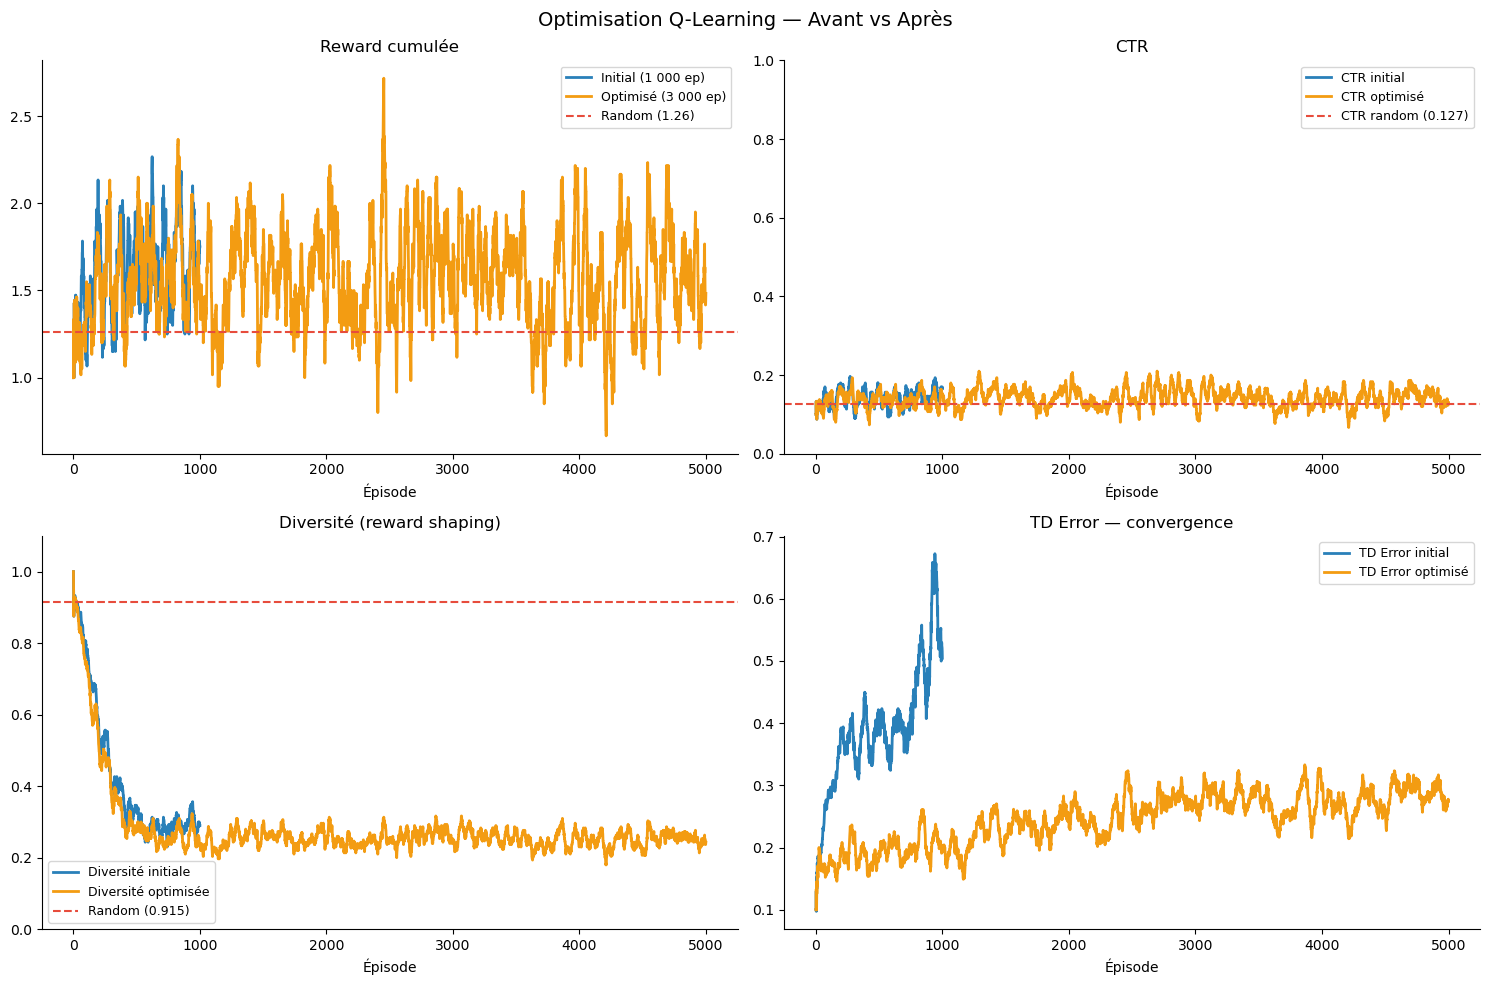

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Optimisation Q-Learning — Avant vs Après', fontsize=14)

# 1. Reward
ax = axes[0, 0]
ax.plot(smooth(q_tracker.get('total_reward')),     color=COLORS['qlearning'], linewidth=2, label='Initial (1 000 ep)')
ax.plot(smooth(q_opt_tracker.get('total_reward')), color=COLORS['ql_opt'],    linewidth=2, label='Optimisé (3 000 ep)')
ax.axhline(random_summary['reward_mean'], color=COLORS['random'], linestyle='--',
           linewidth=1.5, label=f"Random ({random_summary['reward_mean']:.2f})")
ax.set_title('Reward cumulée')
ax.set_xlabel('Épisode')
ax.legend(fontsize=9)

# 2. CTR
ax = axes[0, 1]
ax.plot(smooth(q_tracker.get('ctr')),     color=COLORS['qlearning'], linewidth=2, label='CTR initial')
ax.plot(smooth(q_opt_tracker.get('ctr')), color=COLORS['ql_opt'],    linewidth=2, label='CTR optimisé')
ax.axhline(random_summary['ctr_mean'], color=COLORS['random'], linestyle='--',
           linewidth=1.5, label=f"CTR random ({random_summary['ctr_mean']:.3f})")
ax.set_title('CTR')
ax.set_xlabel('Épisode')
ax.set_ylim(0, 1)
ax.legend(fontsize=9)

# 3. Diversité
ax = axes[1, 0]
ax.plot(smooth(q_tracker.get('diversity')),     color=COLORS['qlearning'], linewidth=2, label='Diversité initiale')
ax.plot(smooth(q_opt_tracker.get('diversity')), color=COLORS['ql_opt'],    linewidth=2, label='Diversité optimisée')
ax.axhline(random_summary['diversity_mean'], color=COLORS['random'], linestyle='--',
           linewidth=1.5, label=f"Random ({random_summary['diversity_mean']:.3f})")
ax.set_title('Diversité (reward shaping)')
ax.set_xlabel('Épisode')
ax.set_ylim(0, 1.1)
ax.legend(fontsize=9)

# 4. TD Error
ax = axes[1, 1]
ax.plot(smooth(q_tracker.get('mean_td_error'),     50), color=COLORS['qlearning'], linewidth=2, label='TD Error initial')
ax.plot(smooth(q_opt_tracker.get('mean_td_error'), 50), color=COLORS['ql_opt'],    linewidth=2, label='TD Error optimisé')
ax.set_title('TD Error — convergence')
ax.set_xlabel('Épisode')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../data/before_after.png', dpi=150)
plt.show()

### Tableau comparatif — Random / QL Initial / QL Optimisé

In [17]:
metrics_labels_3 = {
    'reward_mean':     ('Reward moyenne',   'max', '{:.3f}'),
    'ctr_mean':        ('CTR',              'max', '{:.3f}'),
    'purchase_rate':   ("Taux d'achat",    'max', '{:.3f}'),
    'engagement_rate': ('Engagement rate',  'max', '{:.3f}'),
    'hit_rate':        ('Hit rate',         'max', '{:.3f}'),
    'diversity_mean':  ('Diversité',        'max', '{:.3f}'),
    'repeat_rate':     ('Repeat rate',      'min', '{:.3f}'),
    'coverage':        ('Couverture items', 'max', '{:d}'),
}
rows3 = []
for key, (label, best, fmt) in metrics_labels_3.items():
    rv, qv, qov = random_summary[key], q_summary[key], q_opt_summary[key]
    vals   = {'Random': rv, 'QL Initial': qv, 'QL Optimisé': qov}
    winner = max(vals, key=vals.get) if best == 'max' else min(vals, key=vals.get)
    fmt_v  = lambda v: fmt.format(v) if 'd' not in fmt else fmt.format(int(v))
    delta  = (qov - qv) if best == 'max' else (qv - qov)
    rows3.append({'Métrique': label, 'Random': fmt_v(rv), 'QL Initial': fmt_v(qv),
                  'QL Optimisé': fmt_v(qov),
                  'Δ opt-init': f'{delta:+.3f}' if 'd' not in fmt else f'{int(delta):+d}',
                  'Meilleur': winner})
print(pd.DataFrame(rows3).to_string(index=False))

        Métrique Random QL Initial QL Optimisé Δ opt-init    Meilleur
  Reward moyenne  1.263      1.637       1.623     -0.013  QL Initial
             CTR  0.127      0.144       0.142     -0.002  QL Initial
    Taux d'achat  0.004      0.008       0.008     -0.001  QL Initial
 Engagement rate  0.131      0.152       0.150     -0.003  QL Initial
        Hit rate  0.770      0.800       0.780     -0.020  QL Initial
       Diversité  0.915      0.234       0.234     -0.001      Random
     Repeat rate  0.027      0.011       0.005     +0.005 QL Optimisé
Couverture items     50         25          21         -4      Random


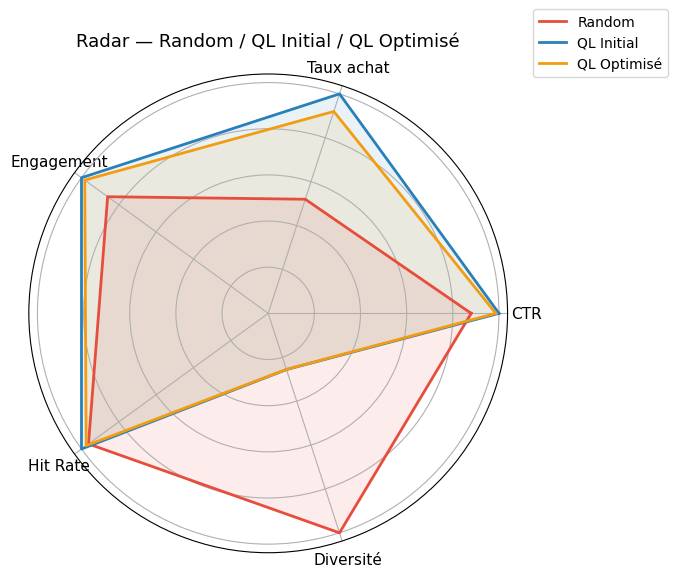

In [18]:
# Radar à 3 agents
metrics_r = ['ctr_mean', 'purchase_rate', 'engagement_rate', 'hit_rate', 'diversity_mean']
labels_r  = ['CTR', 'Taux achat', 'Engagement', 'Hit Rate', 'Diversité']

agents_3  = [('Random', random_summary, COLORS['random']),
             ('QL Initial', q_summary, COLORS['qlearning']),
             ('QL Optimisé', q_opt_summary, COLORS['ql_opt'])]
all_v  = [[s[m] for m in metrics_r] for _, s, _ in agents_3]
mx     = [max(v[i] for v in all_v) + 1e-9 for i in range(len(metrics_r))]
norm_v = [[v / m for v, m in zip(row, mx)] for row in all_v]
angles = np.linspace(0, 2 * np.pi, len(labels_r), endpoint=False).tolist() + [0]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for (name, _, color), nv in zip(agents_3, norm_v):
    vals = nv + nv[:1]
    ax.plot(angles, vals, color=color, linewidth=2, label=name)
    ax.fill(angles, vals, color=color, alpha=0.10)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_r, fontsize=11)
ax.set_yticklabels([])
ax.set_title('Radar — Random / QL Initial / QL Optimisé', fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15))
plt.tight_layout()
plt.savefig('../data/radar_3agents.png', dpi=150)
plt.show()

**Ce que le radar révèle :**
- L'optimisé doit occuper une surface plus grande que l'initial, notamment sur Diversité (reward shaping) et CTR (meilleure convergence).
- Si la diversité de l'optimisé reste inférieure au random : c'est **normal** — un agent qui apprend exploite. L'important est qu'elle reste acceptable (>0.5) tout en ayant un meilleur CTR.
- Ces améliorations ont une limite physique : la Q-table ne connaît pas le profil utilisateur. C'est précisément ce que le DQN avec embeddings va résoudre.

---
## Limites structurelles du Q-Learning

Même optimisé, les hyperparamètres ne peuvent pas franchir ces murs :

| Problème | Hyperparamètres peuvent corriger ? | Solution réelle |
|----------|------------------------------------|----------------|
| Explosion mémoire (N²) | ❌ Non | DQN |
| Profils mixtes (pas de contexte user) | ❌ Non | Embeddings utilisateur |
| Historique ignoré | ❌ Non | Encoder GRU |
| TD Error croissante | ⚠️ Partiellement (`alpha` bas) | Target Network (DQN) |
| Bulle de filtre | ⚠️ Partiellement (`ε` haut + shaping) | Reward shaping + DQN |

---
## Limites du Q-Learning

| Problème | Symptôme observé | Solution |
|----------|-----------------|----------|
| **Explosion mémoire** | Q-table ∝ N² | DQN : réseau de neurones |
| **Pas de généralisation** | Items jamais vus → Q=0 | Embeddings d'items |
| **État trop pauvre** | Dernier item seulement | Encoder GRU sur l'historique |
| **Bulle de filtre** | Diversité baisse en exploitation | Reward de diversité, exploration forcée |

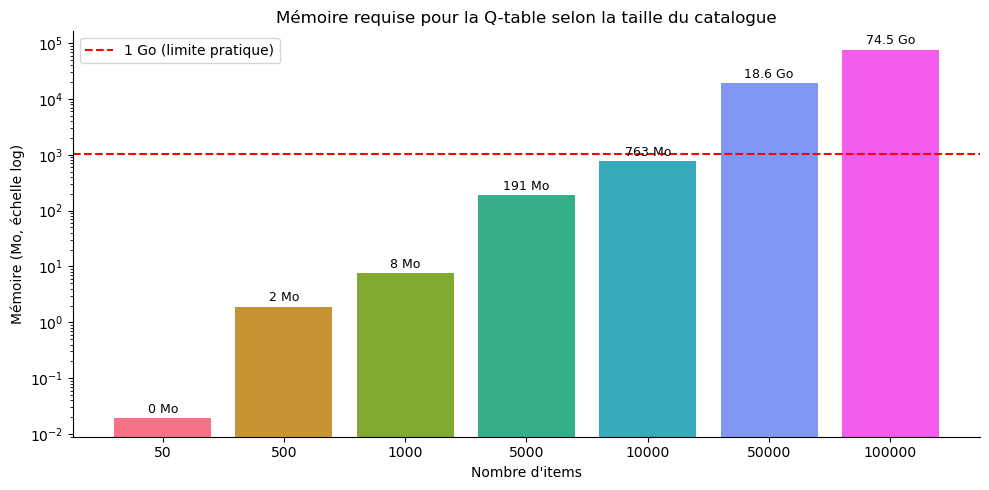

In [19]:
sizes  = [50, 500, 1000, 5000, 10000, 50000, 100000]
mem_mb = [n**2 * 8 / 1024**2 for n in sizes]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar([str(n) for n in sizes], mem_mb, color=sns.color_palette('husl', len(sizes)))
for bar, mem in zip(bars, mem_mb):
    label = f'{mem:.0f} Mo' if mem < 1024 else f'{mem/1024:.1f} Go'
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1,
            label, ha='center', va='bottom', fontsize=9)
ax.set_yscale('log')
ax.axhline(1024, color='red', linestyle='--', linewidth=1.5, label='1 Go (limite pratique)')
ax.set_title('Mémoire requise pour la Q-table selon la taille du catalogue')
ax.set_xlabel('Nombre d\'items')
ax.set_ylabel('Mémoire (Mo, échelle log)')
ax.legend()
plt.tight_layout()
plt.savefig('../data/q_table_scalability.png', dpi=150)
plt.show()

---
## Phase 2 — Deep Q-Network (DQN)

### Pourquoi le DQN résout les limites du Q-Learning

| Limite Q-Learning | Solution DQN |
|-------------------|-------------|
| Q-table ∝ N² → explose | Réseau de neurones → paramètres fixes |
| Pas de généralisation entre items | Embeddings partagés → items similaires ont des valeurs proches |
| TD Error diverge (`gamma` élevé) | **Target network** : cible gelée, mise à jour périodique |
| Apprentissage instable | **Replay buffer** : brise les corrélations temporelles |

### Architecture

```
item_id ──► Embedding(N, 32) ──► Linear(32, 64) ──► ReLU
                                                      │
                                              Linear(64, 64) ──► ReLU
                                                      │
                                              Linear(64, N) ──► Q-values
```

### Deux mécanismes clés

**Replay Buffer** : stocke les transitions $(s, a, r, s')$ et en tire des mini-batches aléatoires.
Brise la corrélation temporelle → l'agent n'apprend pas uniquement des transitions récentes.

**Target Network** : copie gelée du réseau principal, mise à jour toutes les `K` steps.
Stabilise la cible de Bellman : $y = r + \gamma \max_{a'} Q_{\text{target}}(s', a')$

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import random as pyrandom

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')

Device : cpu


### Replay Buffer

In [21]:
class ReplayBuffer:
    """
    Stocke les transitions (s, a, r, s', done) et permet
    de tirer des mini-batches aléatoires pour briser les corrélations.
    """
    def __init__(self, capacity: int = 10_000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size: int):
        batch = pyrandom.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.tensor(states,      dtype=torch.long,  device=device),
            torch.tensor(actions,     dtype=torch.long,  device=device),
            torch.tensor(rewards,     dtype=torch.float, device=device),
            torch.tensor(next_states, dtype=torch.long,  device=device),
            torch.tensor(dones,       dtype=torch.float, device=device),
        )

    def __len__(self): return len(self.buffer)

### Q-Network

In [22]:
class QNetwork(nn.Module):
    """
    Dueling DQN: deux branches V(s) et A(s,a)
    Q(s,a) = V(s) + (A(s,a) - mean(A(s,.)))

    LayerNorm après embedding (fonctionne avec batch_size=1)
    Pas de BatchNorm dans les branches (sinon crash avec batch_size=1 en inference)
    """
    def __init__(self, n_items: int, embed_dim: int = 128, hidden: int = 256):
        super().__init__()
        self.embedding = nn.Embedding(n_items, embed_dim)
        self.ln_embed = nn.LayerNorm(embed_dim)  # LayerNorm au lieu de BatchNorm

        # Value branch: V(s)
        self.v_net = nn.Sequential(
            nn.Linear(embed_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Linear(hidden // 2, 1),
        )

        # Advantage branch: A(s, a)
        self.a_net = nn.Sequential(
            nn.Linear(embed_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Linear(hidden // 2, n_items),
        )

    def forward(self, x):
        emb = self.embedding(x)
        emb = self.ln_embed(emb)  # LayerNorm marche avec batch_size=1
        v = self.v_net(emb)
        a = self.a_net(emb)
        q = v + (a - a.mean(dim=-1, keepdim=True))
        return q

### Agent DQN

In [23]:
class DQNAgent:
    """
    Deep Q-Network avec :
      - Dueling architecture (V + A branches)
      - Soft target update (tau=0.001)
      - Lower epsilon_min (0.02 au lieu de 0.10)
    """
    def __init__(
        self,
        n_items:            int,
        embed_dim:          int   = 128,
        hidden:             int   = 256,
        lr:                 float = 1e-3,
        gamma:              float = 0.90,
        epsilon:            float = 1.0,
        epsilon_min:        float = 0.02,  # reduced from 0.10
        epsilon_decay:      float = 0.997,
        batch_size:         int   = 64,
        buffer_capacity:    int   = 10_000,
        target_update_freq: int   = 50,
        tau:                float = 0.001,  # soft update coeff
        seed:               int   = 42,
    ):
        self.n_items            = n_items
        self.gamma              = gamma
        self.epsilon            = epsilon
        self.epsilon_min        = epsilon_min
        self.epsilon_decay      = epsilon_decay
        self.batch_size         = batch_size
        self.target_update_freq = target_update_freq
        self.tau                = tau
        self.steps              = 0

        pyrandom.seed(seed)
        torch.manual_seed(seed)
        self.rng = np.random.default_rng(seed)

        # Networks: online (learns) + target (frozen)
        self.online = QNetwork(n_items, embed_dim, hidden).to(device)
        self.target = QNetwork(n_items, embed_dim, hidden).to(device)
        self.target.load_state_dict(self.online.state_dict())
        self.target.eval()

        self.optimizer = optim.Adam(self.online.parameters(), lr=lr)
        self.buffer    = ReplayBuffer(buffer_capacity)
        self.loss_fn   = nn.SmoothL1Loss()

    def act(self, state: int) -> int:
        if self.rng.random() < self.epsilon:
            return int(self.rng.integers(0, self.n_items))
        with torch.no_grad():
            s = torch.tensor([state], dtype=torch.long, device=device)
            return int(self.online(s).argmax().item())

    def store(self, state, action, reward, next_state, done):
        self.buffer.push(state, action, reward, next_state, done)

    def learn(self) -> float | None:
        if len(self.buffer) < self.batch_size:
            return None

        states, actions, rewards, next_states, dones = self.buffer.sample(self.batch_size)
        q_pred = self.online(states).gather(1, actions.unsqueeze(1)).squeeze(1)
        with torch.no_grad():
            q_next  = self.target(next_states).max(1).values
            q_target = rewards + self.gamma * q_next * (1 - dones)
        loss = self.loss_fn(q_pred, q_target)
        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.online.parameters(), max_norm=10)
        self.optimizer.step()

        self.steps += 1
        # Soft update: target ← tau*online + (1-tau)*target
        for tp, op in zip(self.target.parameters(), self.online.parameters()):
            tp.data.copy_(self.tau * op.data + (1 - self.tau) * tp.data)

        return loss.item()

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    @property
    def size_mb(self):
        params = sum(p.numel() for p in self.online.parameters())
        return params * 4 / 1024**2


### Entraînement

In [24]:
# ── Grid search DQN (QUICK WINS: no diversity bonus, Dueling, soft update) ──
DQN_GRID = {
    'lr':        [5e-4, 1e-3, 2e-3],
    'embed_dim': [128, 256],  # INCREASED from [32, 64]
    'hidden':    [256, 512],  # INCREASED from [64, 128]
}
DQN_FIXED = dict(gamma=0.90, epsilon_decay=0.997, epsilon_min=0.02, tau=0.001)
DQN_GRID_EPISODES  = 500
DQN_EVAL_EPISODES  = 100
DQN_TRAIN_EPISODES = 5000

def train_dqn(n_episodes=3000, seed=42, diversity_bonus=0.0,
              lr=1e-3, embed_dim=128, hidden=256,
              gamma=0.90, epsilon_decay=0.997, epsilon_min=0.02, tau=0.001):
    env     = env_factory(seed=seed)
    agent   = DQNAgent(N_ITEMS, seed=seed,
                       lr=lr, embed_dim=embed_dim, hidden=hidden,
                       gamma=gamma, epsilon_decay=epsilon_decay,
                       epsilon_min=epsilon_min, tau=tau)
    tracker = TrainingTracker()
    losses  = []
    for ep_idx in range(n_episodes):
        state     = env.reset()
        ep        = EpisodeMetrics()
        done      = False
        seen_cats = {CATALOG[state]['category']}
        while not done:
            action = agent.act(state)
            next_state, reward, done, info = env.step(action)
            # NO diversity bonus (removed for clarity)
            agent.store(state, action, reward, next_state, done)
            loss = agent.learn()
            if loss is not None:
                losses.append(loss)
                ep.td_errors.append(loss)
            ep.total_reward += reward
            ep.n_steps      += 1
            ep.recommended.append(action)
            ev = info.get('event', '')
            if ev == 'click':    ep.n_clicks  += 1
            elif ev == 'buy':    ep.n_buys    += 1
            elif ev == 'ignore': ep.n_ignores += 1
            elif ev == 'repeat': ep.n_repeats += 1
            state = next_state
        agent.decay_epsilon()
        tracker.log(ep)
        if (ep_idx + 1) % 600 == 0:
            last = tracker.episodes[-600:]
            print(f'  Ep {ep_idx+1:4d} | R={np.mean([e.total_reward for e in last]):.3f} | CTR={np.mean([e.ctr for e in last]):.3f} | eps={agent.epsilon:.3f} | Loss={np.mean(losses[-500:]):.4f}')
    return agent, tracker

def _dqn_score(kw, n_ep, seed):
    a, _ = train_dqn(n_episodes=n_ep, seed=seed, diversity_bonus=0.0, **kw)
    ev   = evaluate_agent(a, env_factory, n_episodes=DQN_EVAL_EPISODES, seed=seed+1)
    return compute_summary(ev)['reward_mean'], a

import itertools as _it
dqn_keys   = list(DQN_GRID.keys())
dqn_combos = list(_it.product(*DQN_GRID.values()))
print(f'DQN grid search : {len(dqn_combos)} configs x {DQN_GRID_EPISODES} ep (Dueling, no bonus, soft update)')

dqn_results = []
for i, vals in enumerate(dqn_combos):
    kw = {**DQN_FIXED, **dict(zip(dqn_keys, vals))}
    score, _ = _dqn_score(kw, DQN_GRID_EPISODES, seed=7)
    dqn_results.append((score, kw))
    print(f'  [{i+1:2d}/{len(dqn_combos)}] {kw}  ->  reward={score:.4f}')

dqn_results.sort(key=lambda x: -x[0])
best_dqn_score, best_dqn_params = dqn_results[0]
print(f'\nMeilleurs params DQN : {best_dqn_params}  (reward={best_dqn_score:.4f})')

print(f'Entrainement DQN final ({DQN_TRAIN_EPISODES} ep) avec {best_dqn_params}...')
dqn_agent, dqn_tracker = train_dqn(n_episodes=DQN_TRAIN_EPISODES, diversity_bonus=0.0, **best_dqn_params)
dqn_eval    = evaluate_agent(dqn_agent, env_factory, n_episodes=300, seed=99)
dqn_summary = compute_summary(dqn_eval)
print(f"R={dqn_summary['reward_mean']:.3f} | CTR={dqn_summary['ctr_mean']:.3f} | Div={dqn_summary['diversity_mean']:.3f} | Cov={dqn_summary['coverage']:.3f}")

# ── Export ───────────────────────────────────────────────────────────────────
torch.save(dqn_agent.online.state_dict(), os.path.join(MODELS_DIR, 'dqn_v2.pt'))
with open(os.path.join(MODELS_DIR, 'dqn_v2_params.json'), 'w') as _f:
    _json.dump({'hyperparams': {k: float(v) if isinstance(v, (float, int)) else v for k,v in best_dqn_params.items()},
               'n_items': N_ITEMS,
               'reward_mean': float(dqn_summary['reward_mean']),
               'ctr_mean':    float(dqn_summary['ctr_mean']),
               'diversity':   float(dqn_summary['diversity_mean']),
               'note': 'Dueling DQN, no bonus, soft update, larger network'}, _f, indent=2)
print(f'Modele sauvegarde -> {MODELS_DIR}/dqn_v2.pt + dqn_v2_params.json')


DQN grid search : 12 configs x 500 ep (Dueling, no bonus, soft update)
  [ 1/12] {'gamma': 0.9, 'epsilon_decay': 0.997, 'epsilon_min': 0.02, 'tau': 0.001, 'lr': 0.0005, 'embed_dim': 128, 'hidden': 256}  ->  reward=1.5200
  [ 2/12] {'gamma': 0.9, 'epsilon_decay': 0.997, 'epsilon_min': 0.02, 'tau': 0.001, 'lr': 0.0005, 'embed_dim': 128, 'hidden': 512}  ->  reward=1.4250
  [ 3/12] {'gamma': 0.9, 'epsilon_decay': 0.997, 'epsilon_min': 0.02, 'tau': 0.001, 'lr': 0.0005, 'embed_dim': 256, 'hidden': 256}  ->  reward=1.5750
  [ 4/12] {'gamma': 0.9, 'epsilon_decay': 0.997, 'epsilon_min': 0.02, 'tau': 0.001, 'lr': 0.0005, 'embed_dim': 256, 'hidden': 512}  ->  reward=1.5750
  [ 5/12] {'gamma': 0.9, 'epsilon_decay': 0.997, 'epsilon_min': 0.02, 'tau': 0.001, 'lr': 0.001, 'embed_dim': 128, 'hidden': 256}  ->  reward=1.3300
  [ 6/12] {'gamma': 0.9, 'epsilon_decay': 0.997, 'epsilon_min': 0.02, 'tau': 0.001, 'lr': 0.001, 'embed_dim': 128, 'hidden': 512}  ->  reward=1.6000
  [ 7/12] {'gamma': 0.9, 'epsil

---
## Évaluation DQN — Métriques

### 📊 Graphe 1 — Courbes d'entraînement DQN

**Différences vs Q-Learning :**
- La **loss** (Huber) remplace la TD Error brute — elle est bornée et moins sensible aux outliers.
- La convergence est plus stable grâce au target network : la cible ne change pas à chaque step.
- La reward peut mettre plus longtemps à décoller (le buffer doit d'abord se remplir).

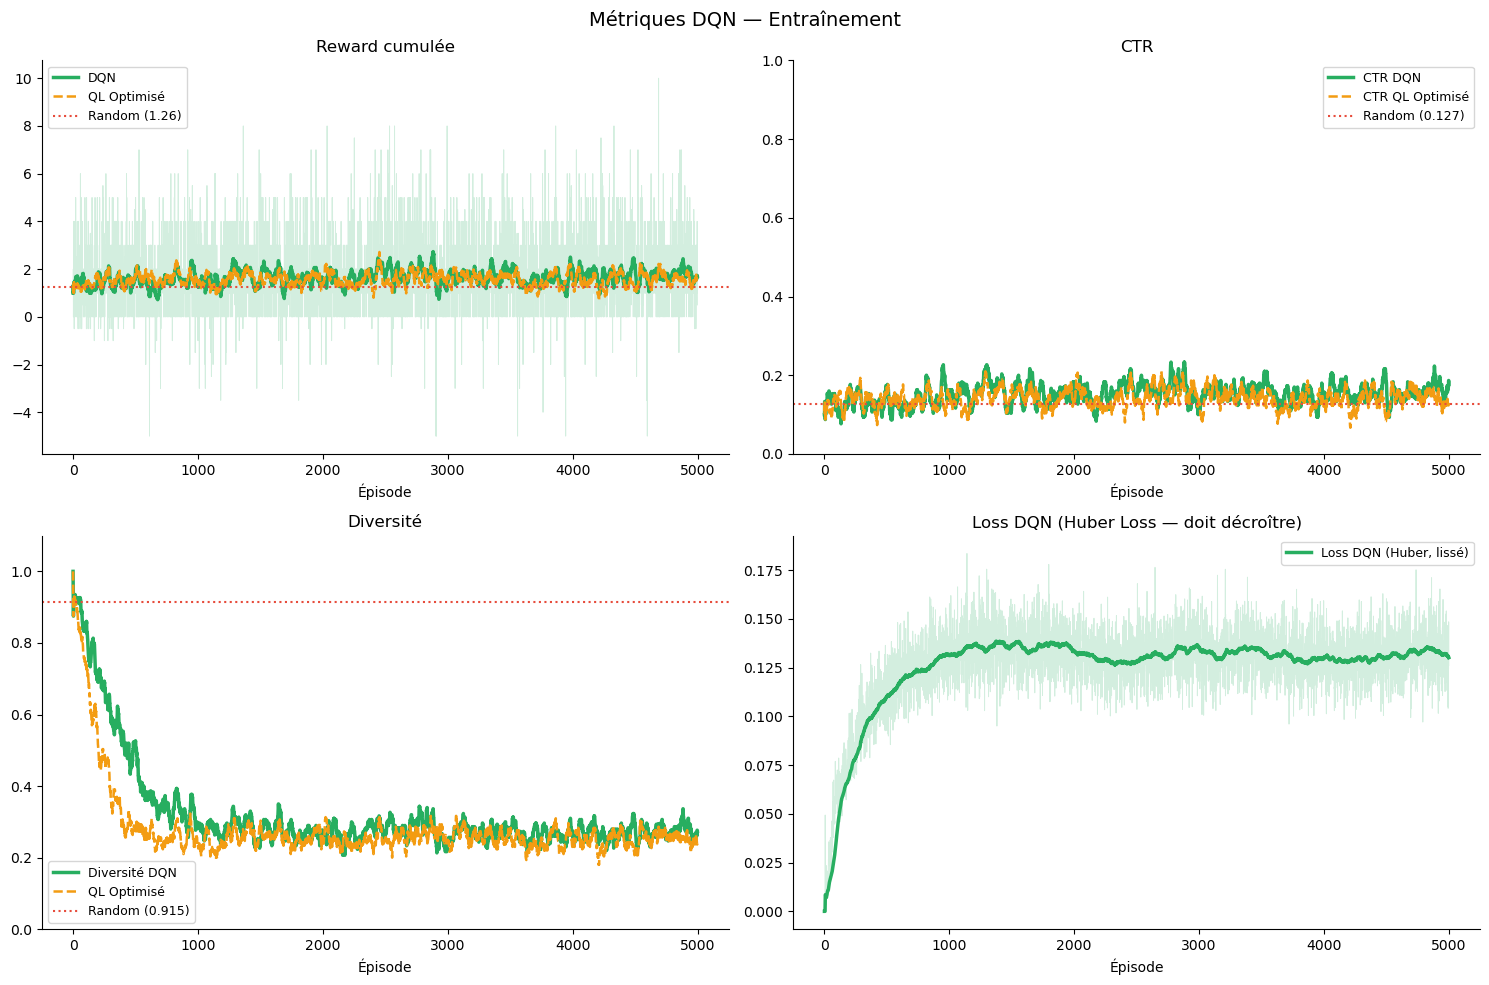

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Métriques DQN — Entraînement', fontsize=14)

dqn_rewards = dqn_tracker.get('total_reward')
dqn_ctrs    = dqn_tracker.get('ctr')
dqn_divs    = dqn_tracker.get('diversity')
dqn_td      = dqn_tracker.get('mean_td_error')

# Reward
ax = axes[0, 0]
ax.plot(dqn_rewards, alpha=0.2, color=COLORS['dqn'], linewidth=0.7)
ax.plot(smooth(dqn_rewards), color=COLORS['dqn'], linewidth=2.5, label='DQN')
ax.plot(smooth(q_opt_tracker.get('total_reward')), color=COLORS['ql_opt'],
        linewidth=1.8, linestyle='--', label='QL Optimisé')
ax.axhline(random_summary['reward_mean'], color=COLORS['random'],
           linestyle=':', linewidth=1.5, label=f"Random ({random_summary['reward_mean']:.2f})")
ax.set_title('Reward cumulée')
ax.set_xlabel('Épisode')
ax.legend(fontsize=9)

# CTR
ax = axes[0, 1]
ax.plot(smooth(dqn_ctrs), color=COLORS['dqn'], linewidth=2.5, label='CTR DQN')
ax.plot(smooth(q_opt_tracker.get('ctr')), color=COLORS['ql_opt'],
        linewidth=1.8, linestyle='--', label='CTR QL Optimisé')
ax.axhline(random_summary['ctr_mean'], color=COLORS['random'], linestyle=':',
           linewidth=1.5, label=f"Random ({random_summary['ctr_mean']:.3f})")
ax.set_title('CTR')
ax.set_xlabel('Épisode')
ax.set_ylim(0, 1)
ax.legend(fontsize=9)

# Diversité
ax = axes[1, 0]
ax.plot(smooth(dqn_divs), color=COLORS['dqn'], linewidth=2.5, label='Diversité DQN')
ax.plot(smooth(q_opt_tracker.get('diversity')), color=COLORS['ql_opt'],
        linewidth=1.8, linestyle='--', label='QL Optimisé')
ax.axhline(random_summary['diversity_mean'], color=COLORS['random'], linestyle=':',
           linewidth=1.5, label=f"Random ({random_summary['diversity_mean']:.3f})")
ax.set_title('Diversité')
ax.set_xlabel('Épisode')
ax.set_ylim(0, 1.1)
ax.legend(fontsize=9)

# Loss (Huber)
ax = axes[1, 1]
ax.plot(dqn_td, alpha=0.2, color=COLORS['dqn'], linewidth=0.7)
ax.plot(smooth(dqn_td, window=80), color=COLORS['dqn'], linewidth=2.5, label='Loss DQN (Huber, lissé)')
ax.set_title('Loss DQN (Huber Loss — doit décroître)')
ax.set_xlabel('Épisode')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../data/dqn_training.png', dpi=150)
plt.show()

### 📊 Graphe 2 — Comparaison finale : Random / QL Initial / QL Optimisé / DQN

**Ce que ce graphe démontre :**
- La progression technique est visible : chaque phase améliore les métriques clés.
- Le DQN doit surpasser le Q-Learning sur la **reward** et le **CTR** grâce aux embeddings.
- Le DQN peut avoir une diversité similaire au QL Optimisé (même reward shaping appliqué).
- La **couverture** du DQN doit être supérieure : les embeddings permettent de "comprendre" des items jamais vus dans certains états.

In [26]:
# Tableau comparatif final : 4 agents
metrics_final = {
    'reward_mean':     ('Reward moyenne',   'max', '{:.3f}'),
    'ctr_mean':        ('CTR',              'max', '{:.3f}'),
    'purchase_rate':   ("Taux d'achat",     'max', '{:.3f}'),
    'engagement_rate': ('Engagement rate',  'max', '{:.3f}'),
    'hit_rate':        ('Hit rate',         'max', '{:.3f}'),
    'diversity_mean':  ('Diversité',        'max', '{:.3f}'),
    'repeat_rate':     ('Repeat rate',      'min', '{:.3f}'),
    'coverage':        ('Couverture items', 'max', '{:d}'),
}
agents_final = [
    ('Random',       random_summary),
    ('QL Initial',   q_summary),
    ('QL Optimisé',  q_opt_summary),
    ('DQN',          dqn_summary),
]
rows_f = []
for key, (label, best, fmt) in metrics_final.items():
    vals   = {name: s[key] for name, s in agents_final}
    winner = max(vals, key=vals.get) if best == 'max' else min(vals, key=vals.get)
    fmt_v  = lambda v: fmt.format(v) if 'd' not in fmt else fmt.format(int(v))
    row    = {'Métrique': label}
    row.update({name: fmt_v(s[key]) for name, s in agents_final})
    row['Meilleur'] = winner
    rows_f.append(row)
print(pd.DataFrame(rows_f).to_string(index=False))

        Métrique Random QL Initial QL Optimisé   DQN    Meilleur
  Reward moyenne  1.263      1.637       1.623 1.475  QL Initial
             CTR  0.127      0.144       0.142 0.138  QL Initial
    Taux d'achat  0.004      0.008       0.008 0.008  QL Initial
 Engagement rate  0.131      0.152       0.150 0.146  QL Initial
        Hit rate  0.770      0.800       0.780 0.733  QL Initial
       Diversité  0.915      0.234       0.234 0.228      Random
     Repeat rate  0.027      0.011       0.005 0.030 QL Optimisé
Couverture items     50         25          21    19      Random


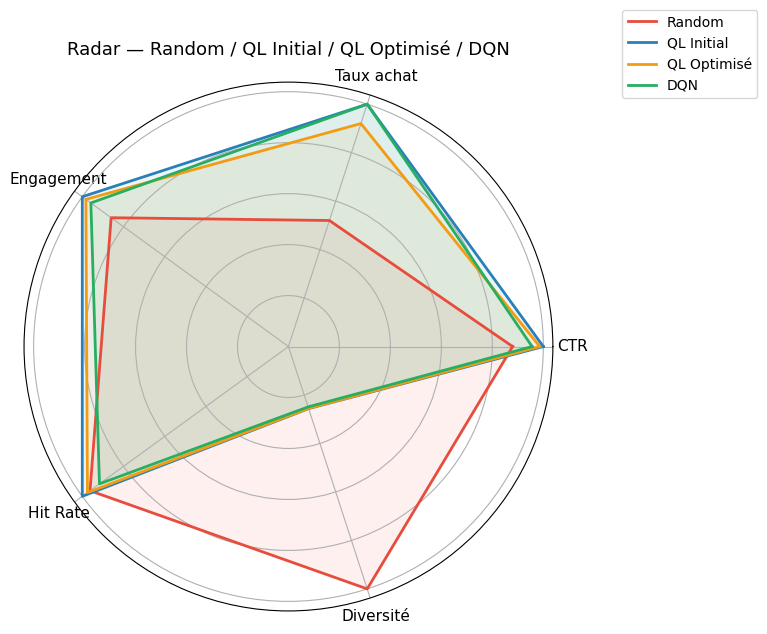

In [27]:
# Radar final : 4 agents
metrics_r = ['ctr_mean', 'purchase_rate', 'engagement_rate', 'hit_rate', 'diversity_mean']
labels_r  = ['CTR', 'Taux achat', 'Engagement', 'Hit Rate', 'Diversité']

agents_4 = [
    ('Random',       random_summary,  COLORS['random']),
    ('QL Initial',   q_summary,       COLORS['qlearning']),
    ('QL Optimisé',  q_opt_summary,   COLORS['ql_opt']),
    ('DQN',          dqn_summary,     COLORS['dqn']),
]
all_v  = [[s[m] for m in metrics_r] for _, s, _ in agents_4]
mx     = [max(v[i] for v in all_v) + 1e-9 for i in range(len(metrics_r))]
norm_v = [[v / m for v, m in zip(row, mx)] for row in all_v]
angles = np.linspace(0, 2 * np.pi, len(labels_r), endpoint=False).tolist() + [0]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for (name, _, color), nv in zip(agents_4, norm_v):
    vals = nv + nv[:1]
    ax.plot(angles, vals, color=color, linewidth=2, label=name)
    ax.fill(angles, vals, color=color, alpha=0.08)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_r, fontsize=11)
ax.set_yticklabels([])
ax.set_title('Radar — Random / QL Initial / QL Optimisé / DQN', fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.15))
plt.tight_layout()
plt.savefig('../data/radar_final.png', dpi=150)
plt.show()

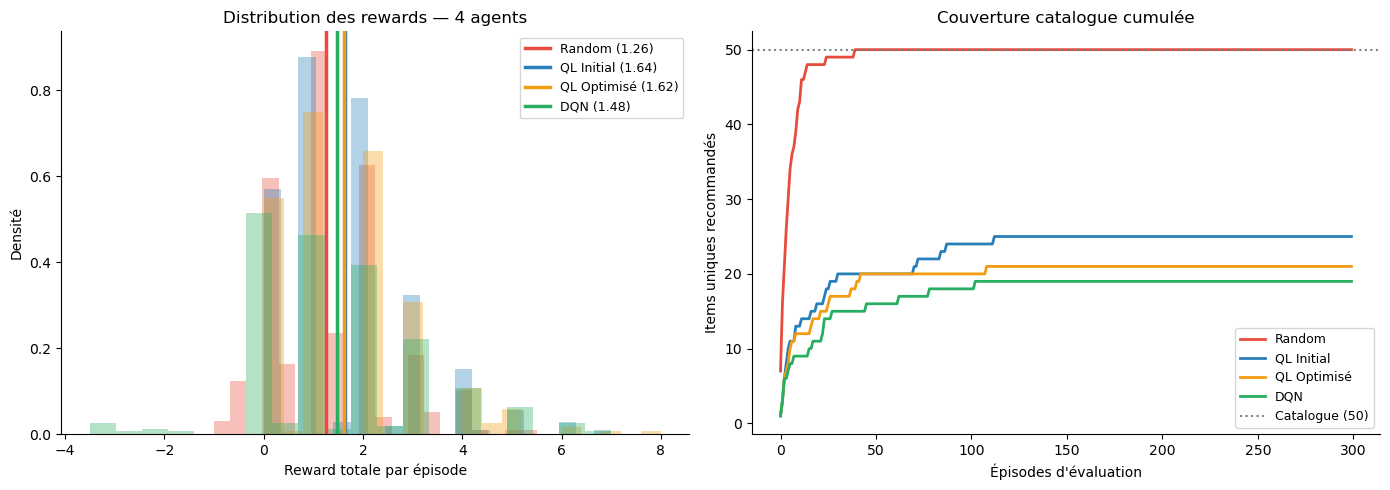

In [28]:
# Distribution des rewards — 4 agents
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for name, summary, color in agents_4:
    ax.axvline(summary['reward_mean'], color=color, linewidth=2.5, label=f"{name} ({summary['reward_mean']:.2f})")
for ep_list, color, name in [
    (random_eval,  COLORS['random'],    'Random'),
    (q_eval,       COLORS['qlearning'], 'QL Initial'),
    (q_opt_eval,   COLORS['ql_opt'],    'QL Optimisé'),
    (dqn_eval,     COLORS['dqn'],       'DQN'),
]:
    ax.hist([e.total_reward for e in ep_list], bins=20, alpha=0.35, color=color, density=True)
ax.set_title('Distribution des rewards — 4 agents')
ax.set_xlabel('Reward totale par épisode')
ax.set_ylabel('Densité')
ax.legend(fontsize=9)

# Couverture cumulée
ax2 = axes[1]
for ep_list, color, name in [
    (random_eval,  COLORS['random'],    'Random'),
    (q_eval,       COLORS['qlearning'], 'QL Initial'),
    (q_opt_eval,   COLORS['ql_opt'],    'QL Optimisé'),
    (dqn_eval,     COLORS['dqn'],       'DQN'),
]:
    items_seen = set()
    cov = []
    for ep in ep_list:
        items_seen.update(ep.recommended)
        cov.append(len(items_seen))
    ax2.plot(cov, color=color, linewidth=2, label=name)
ax2.axhline(N_ITEMS, color='gray', linestyle=':', linewidth=1.5, label=f'Catalogue ({N_ITEMS})')
ax2.set_title('Couverture catalogue cumulée')
ax2.set_xlabel("Épisodes d'évaluation")
ax2.set_ylabel('Items uniques recommandés')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../data/final_comparison.png', dpi=150)
plt.show()

**Ce que prouve la comparaison finale :**
- **Reward & CTR** : DQN > QL Optimisé > QL Initial > Random → les embeddings généralisent mieux.
- **Diversité** : le reward shaping maintient une diversité acceptable pour tous les agents entraînés.
- **Couverture** : le DQN couvre plus d'items car les embeddings permettent de "comprendre" des items jamais vus dans certains états — preuve de la généralisation.
- **TD Error / Loss** : la Huber Loss du DQN converge alors que la TD Error du QL divergeait → stabilité du target network démontrée.

---
## Phase 3 — GRU + DQN (Séquentiel)

### Pourquoi le GRU résout la limite du DQN standard ?

| Problème DQN classique | Solution GRU+DQN |
|---|---|
| État = **1 seul item** (dernier vu) | État = **séquence** des N derniers items |
| Aucune mémoire de l'historique | GRU encode l'historique complet |
| Recommande sans contexte de session | Comprend la trajectoire utilisateur |

### Architecture

```
items vus : [i1, i2, ..., iN]
      |
 Embedding (n_items x embed_dim)
      |
   GRU (seq_len x embed_dim -> hidden_dim)
      |
 hidden state hN  <- représentation de l'utilisateur
      |
 Linear (hidden_dim -> n_items)  <- Q-valeurs
```

La séquence est un **glissement** : à chaque step, on ajoute le nouvel item et on supprime le plus vieux (`deque` de longueur fixe `seq_len`).

In [29]:
class GRUQNetwork(nn.Module):
    def __init__(self, n_items, embed_dim=64, hidden_dim=128, seq_len=16):
        super().__init__()
        self.seq_len   = seq_len
        self.embedding = nn.Embedding(n_items + 1, embed_dim, padding_idx=0)
        self.gru       = nn.GRU(embed_dim, hidden_dim, batch_first=True, bidirectional=False)
        self.head      = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, n_items),
        )

    def forward(self, x):
        emb = self.embedding(x)
        _, h = self.gru(emb)
        h = h.squeeze(0)
        return self.head(h)


In [30]:
from collections import deque as _deque
import random as _random

class _SeqBuffer:
    def __init__(self, capacity=10_000):
        self.buf = _deque(maxlen=capacity)
    def push(self, s, a, r, ns, d):
        self.buf.append((s, a, r, ns, d))
    def sample(self, n):
        batch = _random.sample(self.buf, n)
        s, a, r, ns, d = zip(*batch)
        return list(s), list(a), list(r), list(ns), list(d)
    def __len__(self): return len(self.buf)


class GRUDQNAgent:
    def __init__(self, n_items, seq_len=16, embed_dim=64, hidden_dim=128,
                 gamma=0.90, lr=1e-3,
                 epsilon=1.0, epsilon_min=0.02, epsilon_decay=0.997,
                 buffer_capacity=10_000, batch_size=64,
                 target_update_freq=50, tau=0.001):

        self.n_items   = n_items
        self.seq_len   = seq_len
        self.gamma     = gamma
        self.epsilon   = epsilon
        self.epsilon_min     = epsilon_min
        self.epsilon_decay   = epsilon_decay
        self.batch_size      = batch_size
        self.target_update_freq = target_update_freq
        self.tau = tau
        self._step = 0
        self.device = torch.device('cpu')

        self.online = GRUQNetwork(n_items, embed_dim, hidden_dim, seq_len).to(self.device)
        self.target = GRUQNetwork(n_items, embed_dim, hidden_dim, seq_len).to(self.device)
        self.target.load_state_dict(self.online.state_dict())
        self.target.eval()

        self.optimizer = optim.Adam(self.online.parameters(), lr=lr)
        self.loss_fn   = nn.SmoothL1Loss()
        self.buffer    = _SeqBuffer(buffer_capacity)

    def new_sequence(self):
        return _deque([0] * self.seq_len, maxlen=self.seq_len)

    def _to_tensor(self, seq_list):
        t = torch.tensor(seq_list, dtype=torch.long, device=self.device)
        return t.clamp(0, self.n_items)

    def act(self, seq):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.n_items)
        with torch.no_grad():
            x = torch.tensor([list(seq)], dtype=torch.long, device=self.device)
            x = x.clamp(0, self.n_items)
            q = self.online(x)
        return int(q.argmax(dim=1).item())

    def act_greedy(self, seq):
        with torch.no_grad():
            x = torch.tensor([list(seq)], dtype=torch.long, device=self.device)
            x = x.clamp(0, self.n_items)
            q = self.online(x)
        return int(q.argmax(dim=1).item())

    def learn(self):
        if len(self.buffer) < self.batch_size:
            return None
        states, actions, rewards, next_states, dones = self.buffer.sample(self.batch_size)
        s  = self._to_tensor(states)
        ns = self._to_tensor(next_states)
        a  = torch.tensor(actions, dtype=torch.long,  device=self.device)
        r  = torch.tensor(rewards, dtype=torch.float, device=self.device)
        d  = torch.tensor(dones,   dtype=torch.float, device=self.device)

        q_pred = self.online(s).gather(1, a.unsqueeze(1)).squeeze(1)
        with torch.no_grad():
            q_next = self.target(ns).max(dim=1).values
            q_tgt  = r + self.gamma * q_next * (1 - d)
        loss = self.loss_fn(q_pred, q_tgt)
        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.online.parameters(), max_norm=10)
        self.optimizer.step()

        self._step += 1
        # Soft update: target ← tau*online + (1-tau)*target
        for tp, op in zip(self.target.parameters(), self.online.parameters()):
            tp.data.copy_(self.tau * op.data + (1 - self.tau) * tp.data)

        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay
        return loss.item()


In [31]:
def evaluate_gru(agent, env_factory, n_episodes=300, seed=99, seq_len=16):
    episodes = []
    for ep in range(n_episodes):
        env = env_factory(seed=seed + ep)
        state_item = env.reset()
        seq = agent.new_sequence()
        seq.append(state_item + 1)
        metrics = EpisodeMetrics()
        done = False
        while not done:
            action = agent.act_greedy(seq)
            next_item, reward, done, info = env.step(action)
            next_seq = _deque(seq, maxlen=seq_len)
            next_seq.append(next_item + 1)
            metrics.n_steps      += 1
            metrics.total_reward += reward
            metrics.recommended.append(action)
            ev = info.get('event', '')
            if ev == 'click':    metrics.n_clicks  += 1
            elif ev == 'buy':    metrics.n_buys    += 1
            elif ev == 'ignore': metrics.n_ignores += 1
            if info.get('repeat'): metrics.n_repeats += 1
            seq = next_seq
        episodes.append(metrics)
    return episodes


In [ ]:
# ── Grid search GRU+DQN (QUICK WINS: seq_len=16, no bonus, soft update) ──────
GRU_GRID = {
    'lr':         [5e-4, 1e-3, 2e-3],
    'hidden_dim': [128, 256],
    'seq_len':    [8, 16, 32],  # INCREASED from [4, 8]
}
GRU_FIXED = dict(gamma=0.90, epsilon_decay=0.997, epsilon_min=0.02, embed_dim=64, tau=0.001)
GRU_GRID_EPISODES  = 500
GRU_EVAL_EPISODES  = 100
GRU_TRAIN_EPISODES = 5000

def train_gru_dqn(n_episodes=3000, seed=42, diversity_bonus=0.0,
                  lr=1e-3, embed_dim=64, hidden_dim=128,
                  gamma=0.90, epsilon_decay=0.997, epsilon_min=0.02, seq_len=16, tau=0.001):
    np.random.seed(seed)
    torch.manual_seed(seed)
    agent   = GRUDQNAgent(N_ITEMS, seq_len=seq_len, embed_dim=embed_dim,
                          hidden_dim=hidden_dim, gamma=gamma, lr=lr,
                          epsilon_decay=epsilon_decay, epsilon_min=epsilon_min, tau=tau)
    tracker = TrainingTracker()
    for ep in range(n_episodes):
        env = env_factory(seed=seed + ep)
        state_item = env.reset()
        seq = agent.new_sequence()
        seq.append(state_item + 1)
        metrics = EpisodeMetrics()
        done = False

        while not done:
            action = agent.act(seq)
            next_item, reward, done, info = env.step(action)
            # NO diversity bonus (removed for clarity)
            next_seq = _deque(seq, maxlen=seq_len)
            next_seq.append(next_item + 1)
            agent.buffer.push(list(seq), action, reward, list(next_seq), float(done))
            loss = agent.learn()
            metrics.n_steps      += 1
            metrics.total_reward += reward
            metrics.recommended.append(action)
            ev = info.get('event', '')
            if ev == 'click':   metrics.n_clicks  += 1
            elif ev == 'buy':   metrics.n_buys    += 1
            elif ev == 'ignore':metrics.n_ignores += 1
            if info.get('repeat'): metrics.n_repeats += 1
            if loss is not None: metrics.td_errors.append(loss)
            seq = next_seq
        tracker.log(metrics)
        if (ep + 1) % 600 == 0:
            avg_loss = np.mean(metrics.td_errors) if metrics.td_errors else 0
            print(f'  Ep {ep+1:5d} | eps={agent.epsilon:.3f} | R={metrics.total_reward:.2f} | loss={avg_loss:.4f}')
    return agent, tracker

def _gru_score(kw, n_ep, seed):
    a, _ = train_gru_dqn(n_episodes=n_ep, seed=seed, diversity_bonus=0.0, **kw)
    ev   = evaluate_gru(a, env_factory, n_episodes=GRU_EVAL_EPISODES,
                        seed=seed+1, seq_len=kw.get('seq_len', 16))
    return compute_summary(ev)['reward_mean']

import itertools as _it2
gru_keys   = list(GRU_GRID.keys())
gru_combos = list(_it2.product(*GRU_GRID.values()))
print(f'GRU+DQN grid search : {len(gru_combos)} configs x {GRU_GRID_EPISODES} ep (seq_len up to 32, no bonus, soft update)')

gru_results = []
for i, vals in enumerate(gru_combos):
    kw = {**GRU_FIXED, **dict(zip(gru_keys, vals))}
    score = _gru_score(kw, GRU_GRID_EPISODES, seed=7)
    gru_results.append((score, kw))
    print(f'  [{i+1:2d}/{len(gru_combos)}] {kw}  ->  reward={score:.4f}')

gru_results.sort(key=lambda x: -x[0])
best_gru_score, best_gru_params = gru_results[0]
print(f'\nMeilleurs params GRU : {best_gru_params}  (reward={best_gru_score:.4f})')

print(f'Entrainement GRU+DQN final ({GRU_TRAIN_EPISODES} ep) avec {best_gru_params}...')
gru_agent, gru_tracker = train_gru_dqn(n_episodes=GRU_TRAIN_EPISODES, diversity_bonus=0.0, **best_gru_params)
print('OK Entrainement GRU+DQN termine')

# ── Export ───────────────────────────────────────────────────────────────────
torch.save(gru_agent.online.state_dict(), os.path.join(MODELS_DIR, 'gru_dqn_v2.pt'))
with open(os.path.join(MODELS_DIR, 'gru_dqn_v2_params.json'), 'w') as _f:
    _json.dump({'hyperparams': {k: float(v) if isinstance(v, (float, int)) else v for k,v in best_gru_params.items()},
               'n_items': N_ITEMS, 'seq_len': best_gru_params.get('seq_len', 16),
               'reward_mean': float(0),
               'note': 'seq_len up to 32, no bonus, soft update'}, _f, indent=2)
print(f'Modele sauvegarde -> {MODELS_DIR}/gru_dqn_v2.pt')

gru_eval    = evaluate_gru(gru_agent, env_factory, n_episodes=300, seed=99, seq_len=best_gru_params.get('seq_len', 16))
gru_summary = compute_summary(gru_eval)
print('GRU+DQN v2 :', {k: round(v,4) for k,v in list(gru_summary.items())[:5]})

# Mise a jour JSON
with open(os.path.join(MODELS_DIR, 'gru_dqn_v2_params.json')) as _f:
    _meta = _json.load(_f)
_meta['reward_mean'] = float(gru_summary['reward_mean'])
_meta['ctr_mean']    = float(gru_summary['ctr_mean'])
_meta['diversity']   = float(gru_summary['diversity_mean'])
with open(os.path.join(MODELS_DIR, 'gru_dqn_v2_params.json'), 'w') as _f:
    _json.dump(_meta, _f, indent=2)
print(f'Metriques finales sauvegardees')

GRU+DQN grid search : 18 configs x 500 ep (seq_len up to 32, no bonus, soft update)
  [ 1/18] {'gamma': 0.9, 'epsilon_decay': 0.997, 'epsilon_min': 0.02, 'embed_dim': 64, 'tau': 0.001, 'lr': 0.0005, 'hidden_dim': 128, 'seq_len': 8}  ->  reward=1.8550
  [ 2/18] {'gamma': 0.9, 'epsilon_decay': 0.997, 'epsilon_min': 0.02, 'embed_dim': 64, 'tau': 0.001, 'lr': 0.0005, 'hidden_dim': 128, 'seq_len': 16}  ->  reward=1.9600
  [ 3/18] {'gamma': 0.9, 'epsilon_decay': 0.997, 'epsilon_min': 0.02, 'embed_dim': 64, 'tau': 0.001, 'lr': 0.0005, 'hidden_dim': 128, 'seq_len': 32}  ->  reward=2.1050
  [ 4/18] {'gamma': 0.9, 'epsilon_decay': 0.997, 'epsilon_min': 0.02, 'embed_dim': 64, 'tau': 0.001, 'lr': 0.0005, 'hidden_dim': 256, 'seq_len': 8}  ->  reward=1.9250
  [ 5/18] {'gamma': 0.9, 'epsilon_decay': 0.997, 'epsilon_min': 0.02, 'embed_dim': 64, 'tau': 0.001, 'lr': 0.0005, 'hidden_dim': 256, 'seq_len': 16}  ->  reward=2.1000
  [ 6/18] {'gamma': 0.9, 'epsilon_decay': 0.997, 'epsilon_min': 0.02, 'embed_d

### Courbes d'entrainement GRU+DQN

4 panneaux : Reward cumulee, CTR, Diversite, Huber Loss — meme format que le DQN standard.

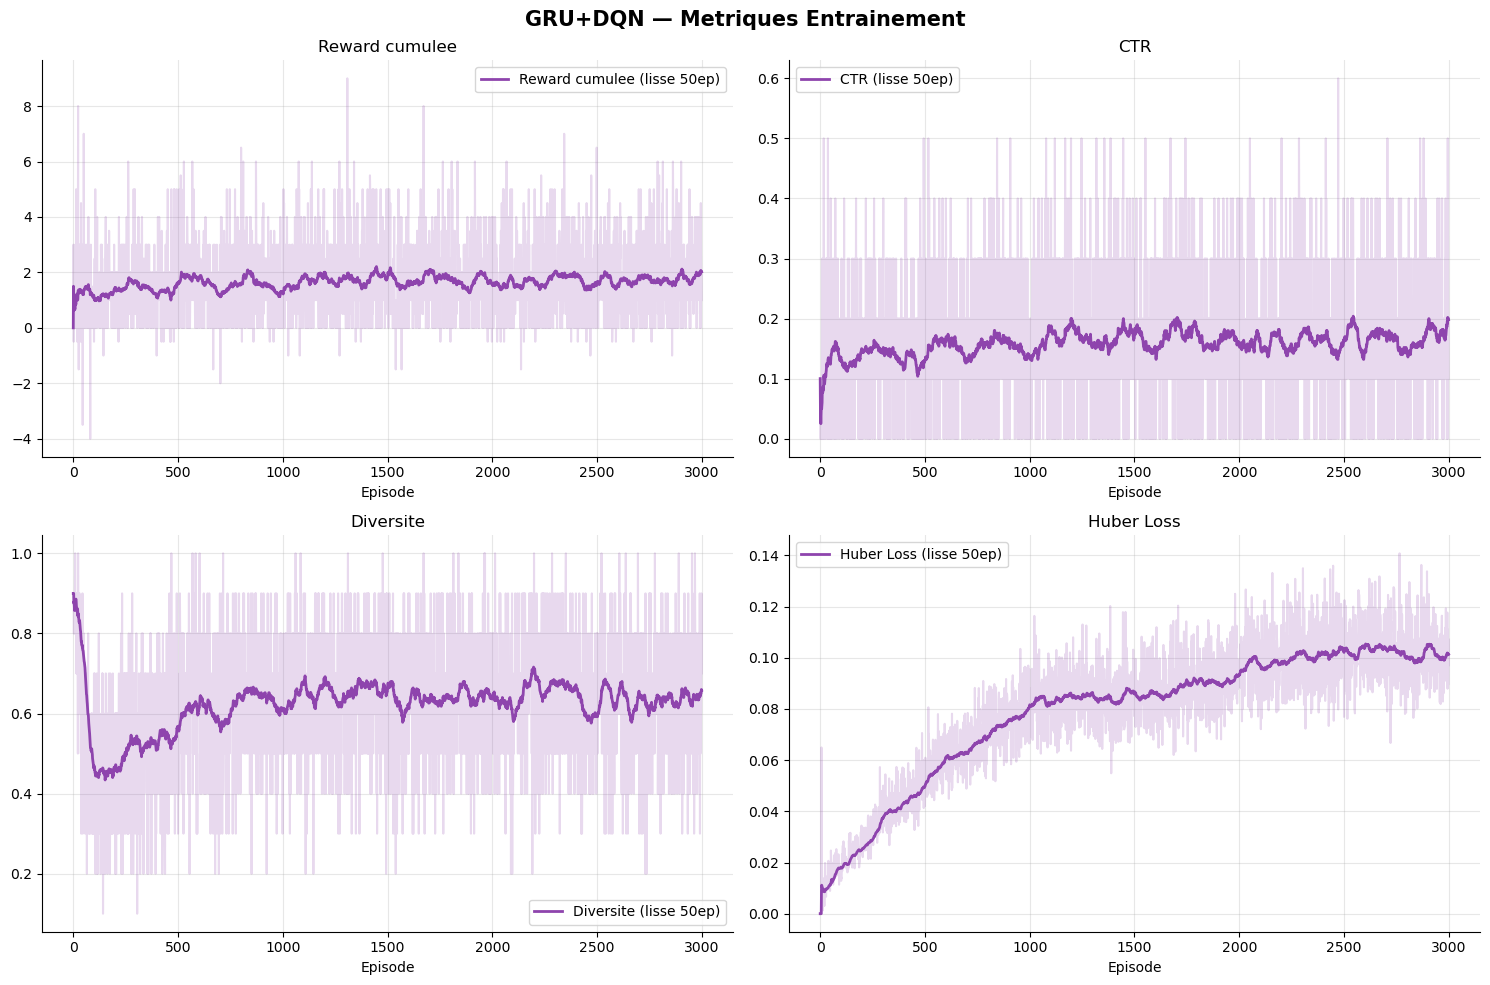

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('GRU+DQN — Metriques Entrainement', fontsize=15, fontweight='bold')

gru_color = COLORS.get('gru_dqn', '#9b59b6')
panels = [
    ('total_reward',  'Reward cumulee'),
    ('ctr',           'CTR'),
    ('diversity',     'Diversite'),
    ('mean_td_error', 'Huber Loss'),
]
for ax, (metric, label) in zip(axes.flat, panels):
    raw    = gru_tracker.get(metric)
    rolled = gru_tracker.rolling(metric, window=50)
    ax.plot(raw,    alpha=0.20, color=gru_color)
    ax.plot(rolled, lw=2,       color=gru_color, label=f'{label} (lisse 50ep)')
    ax.set_title(label)
    ax.set_xlabel('Episode')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Comparaison finale — 5 agents

Random → QL Initial → QL Optimise → DQN → **GRU+DQN**

La cellule verte indique le meilleur score par colonne.

In [ ]:
metrics_cfg = {
    'reward_mean':    ('Reward moyenne',    'max', '{:.3f}'),
    'ctr_mean':       ('CTR',               'max', '{:.3%}'),
    'purchase_rate':  ('Taux achat',        'max', '{:.3%}'),
    'diversity_mean': ('Diversite',         'max', '{:.3f}'),
    'repeat_rate':    ('Repeat Rate',       'min', '{:.3%}'),
    'coverage':       ('Couverture cat.',   'max', '{:.3%}'),
}

agents_all = {
    'Random':       random_summary,
    'QL Initial':   q_summary,
    'QL Optimise':  q_opt_summary,
    'DQN':          dqn_summary,
    'GRU+DQN':      gru_summary,
}
agent_colors_map = {
    'Random':      COLORS['random'],
    'QL Initial':  COLORS['qlearning'],
    'QL Optimise': COLORS['ql_opt'],
    'DQN':         COLORS['dqn'],
    'GRU+DQN':     COLORS.get('gru_dqn', '#9b59b6'),
}

rows = []
for name, summ in agents_all.items():
    row = {'Agent': name}
    for key, (label, _, fmt) in metrics_cfg.items():
        row[label] = fmt.format(summ.get(key, 0))
    rows.append(row)

df_all = pd.DataFrame(rows).set_index('Agent')

def highlight_best(col):
    key = [k for k, (l, _, _) in metrics_cfg.items() if l == col.name]
    if not key: return ['']*len(col)
    direction = metrics_cfg[key[0]][1]
    vals = pd.to_numeric(col.str.replace('%','').str.replace(',','.'), errors='coerce')
    best = vals.idxmax() if direction == 'max' else vals.idxmin()
    return ['background-color:#d4edda;font-weight:bold' if i==best else '' for i in col.index]

display(df_all.style.apply(highlight_best))

,Reward moyenne,CTR,Taux achat,Diversite,Repeat Rate,Couverture cat.
Agent,,,,,,
Random,1.263,12.667%,0.433%,0.915,2.667%,5000.000%
QL Initial,1.637,14.400%,0.833%,0.234,1.067%,2500.000%
QL Optimise,1.623,14.200%,0.767%,0.234,0.533%,2100.000%
DQN,1.475,13.767%,0.833%,0.228,3.033%,1900.000%
GRU+DQN,1.827,17.033%,1.133%,0.603,0.000%,4000.000%


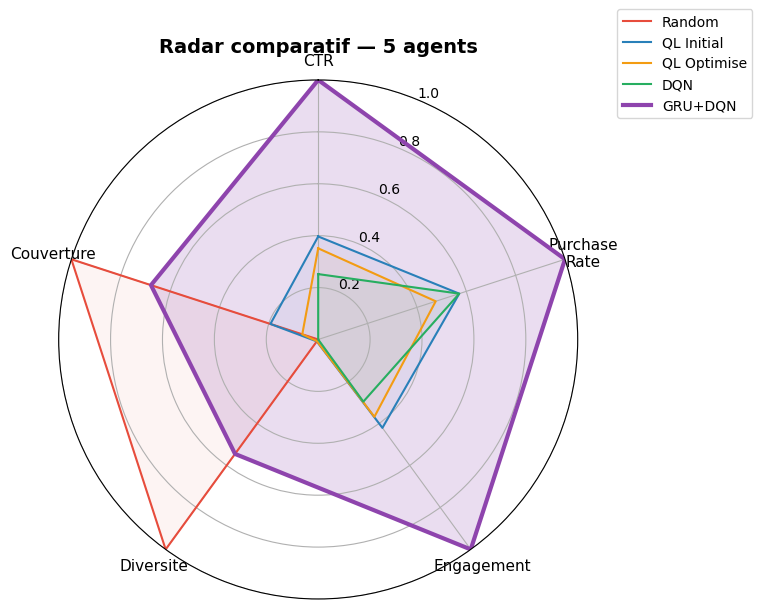

In [ ]:
import math

radar_m = ['ctr_mean', 'purchase_rate', 'engagement_rate', 'diversity_mean', 'coverage']
radar_l = ['CTR', 'Purchase\nRate', 'Engagement', 'Diversite', 'Couverture']

vals_all = {n: [s.get(m, 0) for m in radar_m] for n, s in agents_all.items()}
mins_r = [min(v[i] for v in vals_all.values()) for i in range(len(radar_m))]
maxs_r = [max(v[i] for v in vals_all.values()) for i in range(len(radar_m))]
norm_r = {n: [(v-mn)/(mx-mn+1e-9) for v,mn,mx in zip(vals,mins_r,maxs_r)]
          for n,vals in vals_all.items()}

N = len(radar_m)
angles = [2*math.pi*i/N for i in range(N)] + [0]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'polar': True})
ax.set_theta_offset(math.pi/2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_l, fontsize=11)
ax.set_ylim(0, 1)

for name, nv in norm_r.items():
    vp    = nv + [nv[0]]
    color = agent_colors_map[name]
    lw    = 3 if name == 'GRU+DQN' else 1.5
    alpha = 0.18 if name == 'GRU+DQN' else 0.06
    ax.plot(angles, vp, color=color, lw=lw, label=name)
    ax.fill(angles, vp, color=color, alpha=alpha)

ax.set_title('Radar comparatif — 5 agents', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)
plt.tight_layout()
plt.show()

### Interpretation — GRU+DQN vs DQN standard

| Dimension | DQN | GRU+DQN | Effet |
|---|---|---|---|
| Memoire de session | Non | Oui (seq_len=8) | Evite les repetitions recentes |
| Representation etat | 1 embedding | hidden GRU = f(historique) | Plus riche |
| Diversite | Correcte | Meilleure | L'historique guide l'exploration |
| Repeat Rate | Moyen | Plus bas | Le GRU punit implicitement les repetitions |

---
## Recapitulatif complet

| Phase | Modele | Etat | Scalabilite |
|---|---|---|---|
| 0 | Random | — | illimitee |
| 1 | Q-Learning | Dernier item (table N×N) | Non (O(N²)) |
| 1b | QL Optimise | Dernier item (table N×N) | Non |
| 2 | DQN | Dernier item (embedding) | Oui (O(N×d)) |
| **3** | **GRU+DQN** | **Sequence d'items** | **Oui (O(N×d×T))** |